In [1]:
# Section 0 - Settings
from pathlib import Path

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import yaml
except ModuleNotFoundError:
    yaml = None

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 120})

csv_path = "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/160_string_emax1e6/inference/category1_isMuonCC/baseline/inference/inference_predictions.csv"
pipeline_config_path = "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/160_string_emax1e6/inference/category1_isMuonCC/baseline/inference/pipeline_config.yml"
output_dir = Path("/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/160_string_emax1e6/inference/category1_isMuonCC/baseline/inference")

df = pd.read_csv(csv_path)
if "true_log10_energy" not in df.columns and "true_energy" in df.columns:
    df["true_log10_energy"] = np.log10(df["true_energy"])
if yaml is not None:
    with open(pipeline_config_path) as f:
        pipeline_cfg = yaml.safe_load(f)
    with open(pipeline_cfg["classification"]["config"]) as f:
        classification_cfg = yaml.safe_load(f)
    task_cfg = classification_cfg["task"]
    class_labels = [int(label) for label in task_cfg["labels"]]
    raw_class_names = task_cfg.get("class_names", {}) or {}
    class_names = {int(k): str(v) for k, v in raw_class_names.items()}
else:
    class_labels = sorted(
        int(column.removeprefix("p_class_"))
        for column in df.columns
        if column.startswith("p_class_")
    )
    class_names = {label: f"class {label}" for label in class_labels}
    print("PyYAML is not installed; using class labels inferred from prediction columns.")

true_class_col = "true_classification_class"
pred_class_col = "predicted_route_class"
analysis_group_col = "_pid_interaction_group"
pid_interaction_exact_col = "_pid_interaction_exact_group"
confusion_route_col = "_confusion_route_group"

def class_label(value):
    if pd.isna(value):
        return "missing"
    value = int(value)
    return class_names.get(value, f"class {value}")

def particle_label(pid):
    if pd.isna(pid):
        return "pid missing"
    pid_int = int(pid)
    names = {12: "electron", 14: "muon", 16: "tau"}
    return names.get(abs(pid_int), f"pid {abs(pid_int)}")

def interaction_label(is_cc):
    if pd.isna(is_cc):
        return "interaction missing"
    value_int = int(is_cc)
    names = {1: "CC", 0: "NC"}
    return names.get(value_int, f"is_CC {value_int}")

def pid_interaction_group(pid, is_cc):
    interaction = interaction_label(is_cc)
    if interaction == "NC":
        return "NC"
    return f"{particle_label(pid)} {interaction}"

def pid_interaction_exact_group(pid, is_cc):
    return f"{particle_label(pid)} {interaction_label(is_cc)}"

if {"pid", "is_CC"}.issubset(df.columns):
    df[analysis_group_col] = [pid_interaction_group(pid, is_cc) for pid, is_cc in zip(df["pid"], df["is_CC"])]
    df[pid_interaction_exact_col] = [pid_interaction_exact_group(pid, is_cc) for pid, is_cc in zip(df["pid"], df["is_CC"])]

if {true_class_col, pred_class_col}.issubset(df.columns):
    df[confusion_route_col] = [
        f"true {class_label(true_value)} -> pred {class_label(pred_value)}"
        for true_value, pred_value in zip(df[true_class_col], df[pred_class_col])
    ]

def group_label(key):
    return str(key)

def sigma68(values):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if len(values) == 0:
        return np.nan
    return 0.5 * (np.percentile(values, 84) - np.percentile(values, 16))

def binned_sigma(frame, x_col, residual_col, bins):
    work = frame[[x_col, residual_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if work.empty:
        return pd.DataFrame(columns=["bin_center", "sigma68", "count"])
    work["bin"] = pd.cut(work[x_col], bins=bins, include_lowest=True)
    out = (
        work.groupby("bin", observed=True)[residual_col]
        .agg(count="count", sigma68=sigma68)
        .reset_index()
    )
    out["bin_center"] = out["bin"].map(lambda item: item.mid).astype(float)
    return out

def subplot_grid(n_items, width=5.2, height=4.2):
    ncols = min(2, max(1, n_items))
    nrows = int(math.ceil(n_items / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width * ncols, height * nrows), squeeze=False)
    return fig, axes.ravel()

def grouped_frames(frame):
    if analysis_group_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[analysis_group_col]).groupby(analysis_group_col, sort=True))

def class_grouped_frames(frame):
    if true_class_col not in frame.columns:
        return []
    groups = []
    for key, group in frame.dropna(subset=[true_class_col]).groupby(true_class_col, sort=True):
        groups.append((class_label(key), group))
    return groups

def pid_interaction_grouped_frames(frame):
    if pid_interaction_exact_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[pid_interaction_exact_col]).groupby(pid_interaction_exact_col, sort=True))

def confusion_route_grouped_frames(frame):
    if confusion_route_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[confusion_route_col]).groupby(confusion_route_col, sort=True))

def plot_resolution_and_residual_groups(frame, groups, residual_col, y_label, residual_xlabel, title_prefix, color="tab:blue", hist_bins=80):
    groups = [(label, group.replace([np.inf, -np.inf], np.nan).dropna(subset=["true_log10_energy", residual_col])) for label, group in groups]
    groups = [(label, group) for label, group in groups if not group.empty]
    if not groups:
        print(f"No groups available for {title_prefix}.")
        return None

    fig, axes = plt.subplots(len(groups), 2, figsize=(13, 4.2 * len(groups)), squeeze=False)
    for row, (label, group) in enumerate(groups):
        ax_res, ax_hist = axes[row]

        table = binned_sigma(group, "true_log10_energy", residual_col, bins)
        ax_res.plot(table["bin_center"], table["sigma68"], marker="o", linewidth=2, color=color)
        ax_res.set_title(f"{title_prefix} resolution - {label}")
        ax_res.set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
        ax_res.set_ylabel(y_label)
        ax_res.grid(True, alpha=0.3)

        ax_hist.hist(group[residual_col], bins=hist_bins, histtype="stepfilled", alpha=0.75, color=color)
        ax_hist.axvline(0, color="black", linestyle="--", linewidth=1)
        ax_hist.set_title(f"{title_prefix} residuals - {label}")
        ax_hist.set_xlabel(residual_xlabel)
        ax_hist.set_ylabel("Events")
        ax_hist.grid(True, alpha=0.2)

    fig.tight_layout()
    plt.show()
    return None

df.head()


,event_key,event_no,RunID,SubrunID,EventID,SubEventID,category1_isMuonCC,category2_tauCC_others_muonCC,category_3_contains_muon,position_x,position_y,position_z,pid,is_CC,totalEnergy,zenith,azimuth,finalStateX,finalStateY,finalType1,finalType2,initialType,totalColumnDepth,impactParameter,fully_contained,starting_track,stopping_track,through_going,missed_track,true_classification_class,predicted_route_class,p_class_0,p_class_1,true_energy,true_log10_energy,pred_energy,pred_log10_energy,true_zenith_radian,pred_zenith_radian,true_zenith_degree,pred_zenith_degree,residual_zenith_degree,zenith_kappa,true_azimuth_radian,pred_azimuth_radian,true_azimuth_degree,pred_azimuth_degree,residual_azimuth_degree,azimuth_kappa,pred_azimuth_degree_signed,_pid_interaction_group,_pid_interaction_exact_group,_confusion_route_group
0,232:3:4294967295:16:0,232.0,3.0,4.294967e+09,16.0,0.0,1.0,2.0,1.0,-192.342125,-92.979462,165.810224,14.0,1.0,1548.717647,1.920576,0.100745,0.511322,0.909592,13.0,-2.000001e+09,14.0,717295.152347,113.663414,1.0,0.0,0.0,0.0,0.0,1.0,1,0.111170,0.888830,1548.717647,3.189972,1170.7997,3.068483,1.920576,2.065406,110.040924,118.339060,8.298140,101.321340,0.100745,0.067963,5.772274,3.893987,-1.878288,99.648890,3.893987,muon CC,muon CC,true muon_cc -> pred muon_cc
1,307:19:4294967295:84:0,307.0,19.0,4.294967e+09,84.0,0.0,1.0,2.0,1.0,-89.039511,102.388006,-68.884852,14.0,1.0,805.798208,1.999197,0.142198,0.210781,0.418641,13.0,-2.000001e+09,14.0,539609.146087,147.258017,0.0,1.0,0.0,0.0,0.0,1.0,1,0.087942,0.912058,805.798208,2.906226,706.0225,2.848819,1.999197,1.999848,114.545570,114.582840,0.037272,102.649490,0.142198,0.167987,8.147356,9.624940,1.477588,136.590960,9.624938,muon CC,muon CC,true muon_cc -> pred muon_cc
2,868:4:4294967295:49:0,868.0,4.0,4.294967e+09,49.0,0.0,1.0,2.0,1.0,497.928842,606.305610,-193.270961,14.0,1.0,2346.119251,2.181609,1.668453,0.018592,0.606249,13.0,-2.000001e+09,14.0,854775.746201,577.263261,0.0,0.0,0.0,1.0,0.0,1.0,1,0.115212,0.884788,2346.119251,3.370350,1032.9569,3.014082,2.181609,2.211244,124.997010,126.694970,1.697958,91.617490,1.668453,1.700534,95.595320,97.433410,1.838099,36.436794,97.433420,muon CC,muon CC,true muon_cc -> pred muon_cc
3,1033:47:4294967295:99:0,1033.0,47.0,4.294967e+09,99.0,0.0,1.0,2.0,1.0,-3106.263380,-2559.303818,1466.709251,14.0,1.0,26653.880927,1.303838,3.778179,0.106464,0.536527,13.0,-2.000001e+09,14.0,800902.409811,412.778469,0.0,0.0,1.0,0.0,0.0,1.0,1,0.064831,0.935169,26653.880927,4.425760,31626.4920,4.500051,1.303838,1.304514,74.704414,74.743120,0.038707,76.977264,3.778179,3.767363,216.473720,215.854000,-0.619717,100.294030,-144.146010,muon CC,muon CC,true muon_cc -> pred muon_cc
4,1209:38:4294967295:141:0,1209.0,38.0,4.294967e+09,141.0,0.0,1.0,2.0,1.0,-349.785340,41.402155,1170.733209,-14.0,1.0,14109.925738,0.709025,1.676669,0.005068,0.427999,-13.0,-2.000001e+09,-14.0,336001.586082,782.370203,0.0,0.0,0.0,0.0,1.0,1.0,1,0.077443,0.922557,14109.925738,4.149525,3642.7790,3.561433,0.709025,0.685136,40.624126,39.255398,-1.368729,41.956886,1.676669,1.371008,96.066040,78.552990,-17.513056,11.645558,78.552980,muon CC,muon CC,true muon_cc -> pred muon_cc


## Section 1 - Confusion Matrix


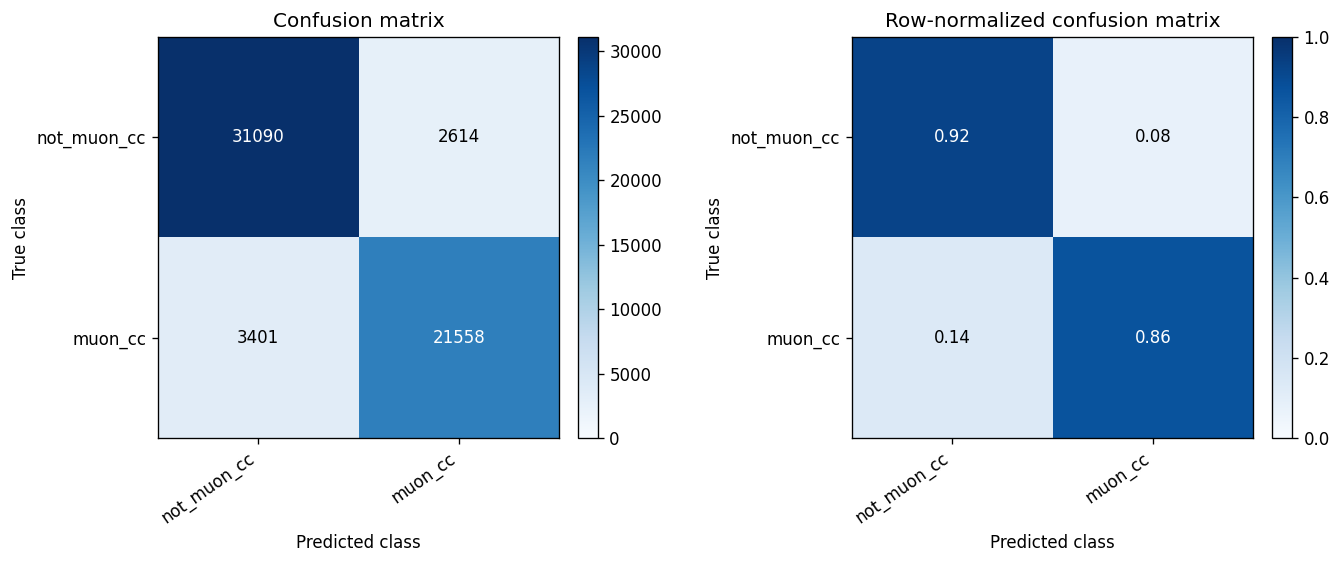

,not_muon_cc,muon_cc
not_muon_cc,31090,2614
muon_cc,3401,21558


In [2]:
def confusion_table(frame):
    work = frame[[true_class_col, pred_class_col]].dropna().copy()
    work[true_class_col] = work[true_class_col].astype(int)
    work[pred_class_col] = work[pred_class_col].astype(int)
    names = [class_label(label) for label in class_labels]
    table = pd.crosstab(work[true_class_col], work[pred_class_col]).reindex(
        index=class_labels, columns=class_labels, fill_value=0
    )
    table.index = names
    table.columns = names
    return table

cm_counts = confusion_table(df)
cm_norm = cm_counts.div(cm_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, table, title, fmt, vmax in [
    (axes[0], cm_counts, "Confusion matrix", "d", None),
    (axes[1], cm_norm, "Row-normalized confusion matrix", ".2f", 1),
]:
    im = ax.imshow(table.values, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_xticks(np.arange(len(table.columns)), labels=table.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(table.index)), labels=table.index)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    threshold = np.nanmax(table.values) / 2 if table.values.size else 0
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            ax.text(j, i, format(value, fmt), ha="center", va="center", color="white" if value > threshold else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

cm_counts


## Section 2 - Energy


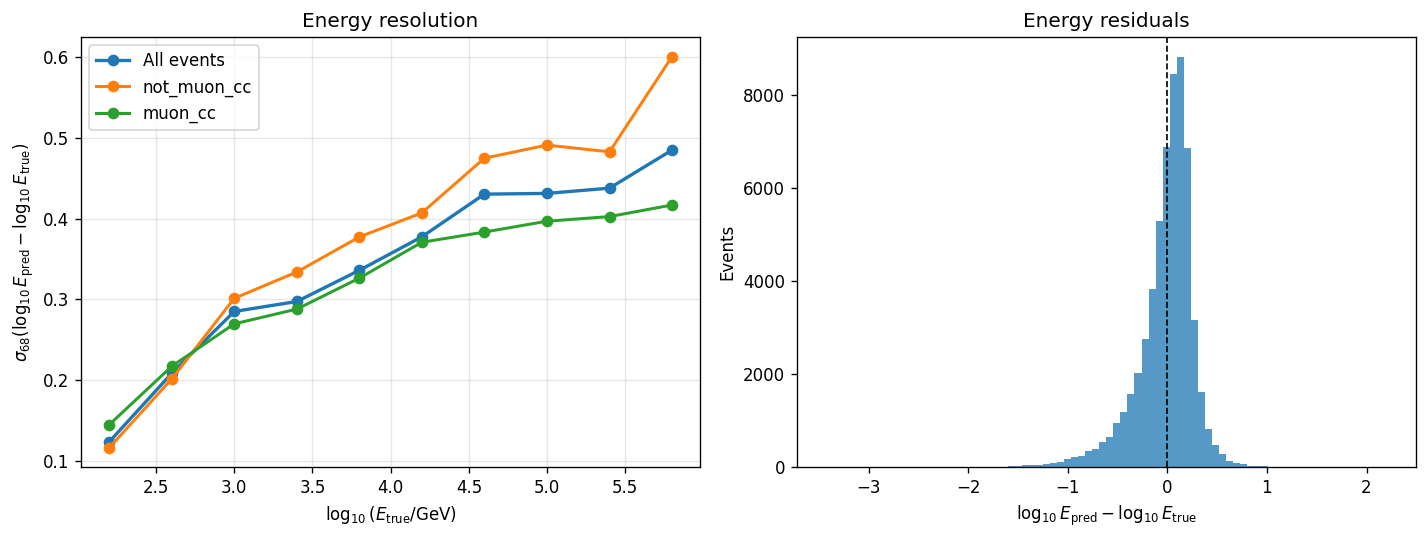

,count,median,mean,sigma68
0,58663,0.038679,-0.017775,0.225424


In [3]:
energy_needed = ["true_energy", "true_log10_energy", "pred_energy", "pred_log10_energy", true_class_col, analysis_group_col, pid_interaction_exact_col, confusion_route_col]
energy_df = df[[col for col in energy_needed if col in df.columns]].dropna().copy()
energy_df = energy_df[(energy_df["true_energy"] > 0) & (energy_df["pred_energy"] > 0)]
energy_df["energy_residual_log10"] = energy_df["pred_log10_energy"] - energy_df["true_log10_energy"]
bins = np.linspace(energy_df["true_log10_energy"].min(), energy_df["true_log10_energy"].max(), 11)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(energy_df, "true_log10_energy", "energy_residual_log10", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in energy_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "energy_residual_log10", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"$\sigma_{68}(\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true})$")
axes[0].set_title("Energy resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(energy_df["energy_residual_log10"], bins=80, histtype="stepfilled", alpha=0.75)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$")
axes[1].set_ylabel("Events")
axes[1].set_title("Energy residuals")
fig.tight_layout()
plt.show()

pd.DataFrame({
    "count": [len(energy_df)],
    "median": [energy_df["energy_residual_log10"].median()],
    "mean": [energy_df["energy_residual_log10"].mean()],
    "sigma68": [sigma68(energy_df["energy_residual_log10"])],
})


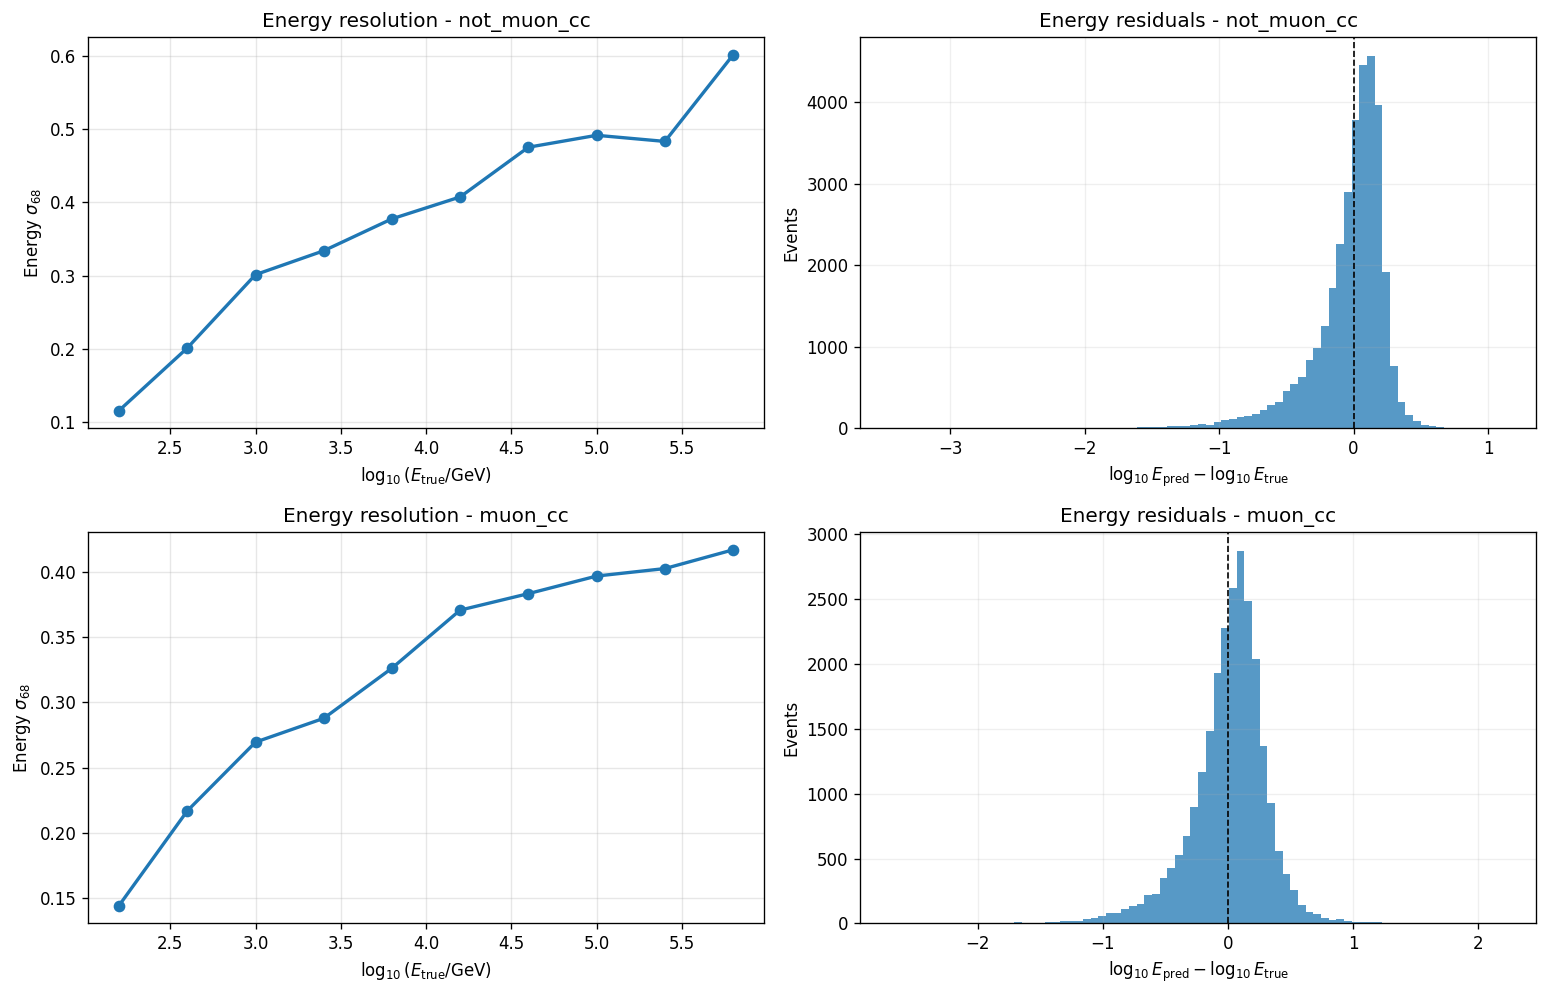

In [4]:
plot_resolution_and_residual_groups(
    energy_df,
    class_grouped_frames(energy_df),
    residual_col="energy_residual_log10",
    y_label=r"Energy $\sigma_{68}$",
    residual_xlabel=r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$",
    title_prefix="Energy",
    color="tab:blue",
)


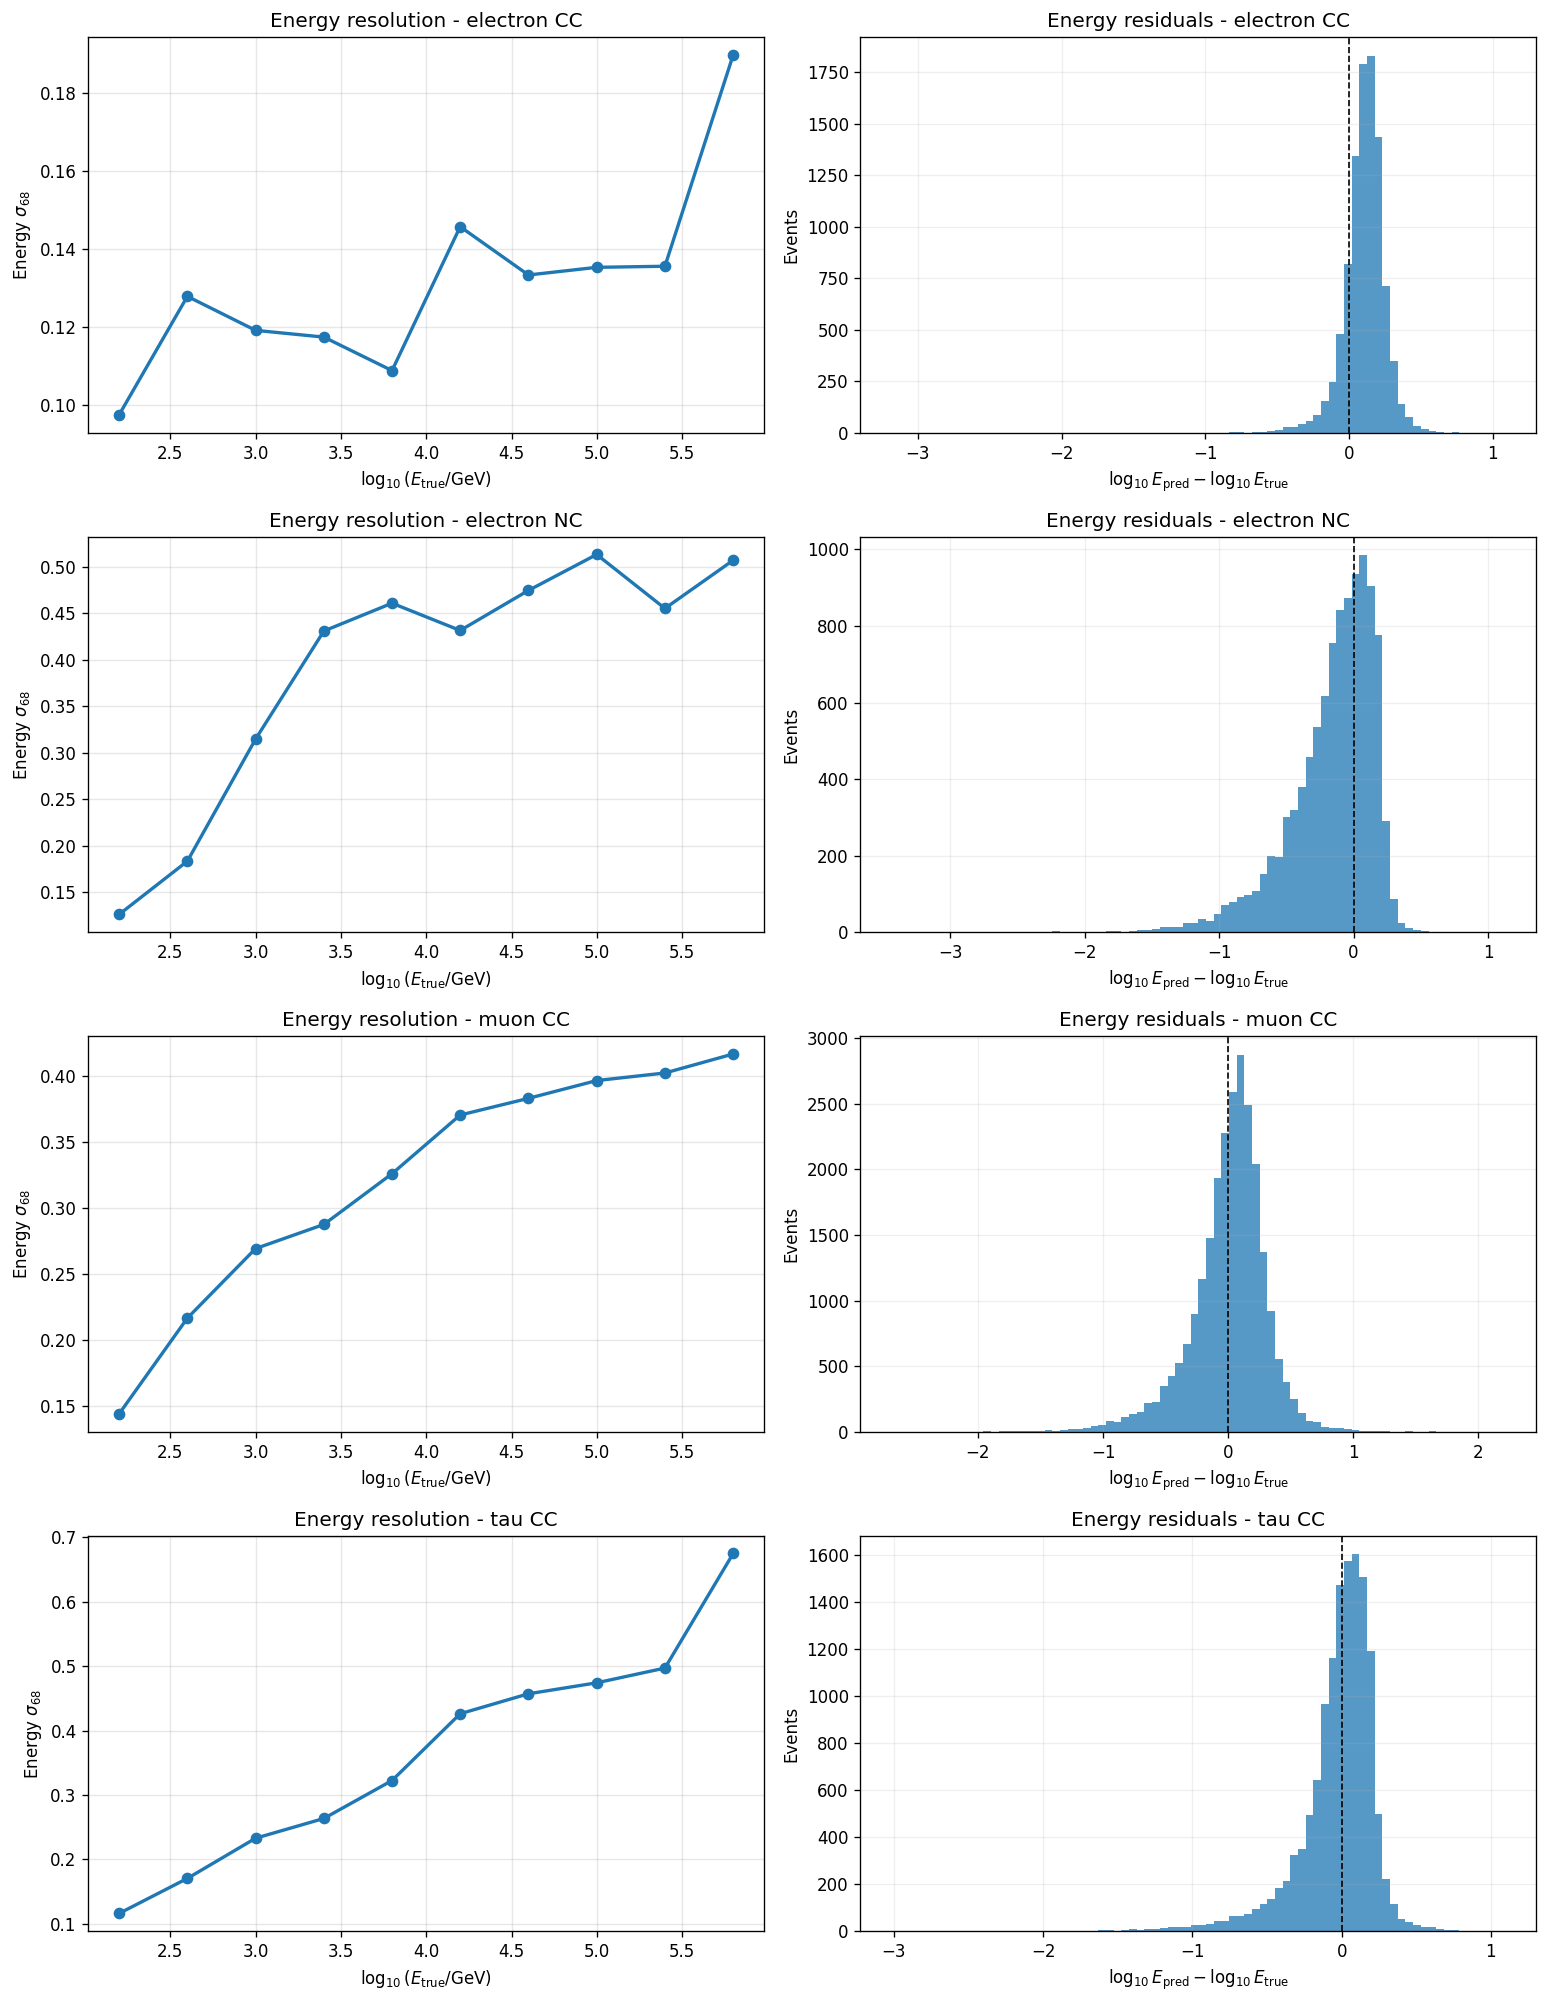

In [5]:
plot_resolution_and_residual_groups(
    energy_df,
    pid_interaction_grouped_frames(energy_df),
    residual_col="energy_residual_log10",
    y_label=r"Energy $\sigma_{68}$",
    residual_xlabel=r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$",
    title_prefix="Energy",
    color="tab:blue",
)


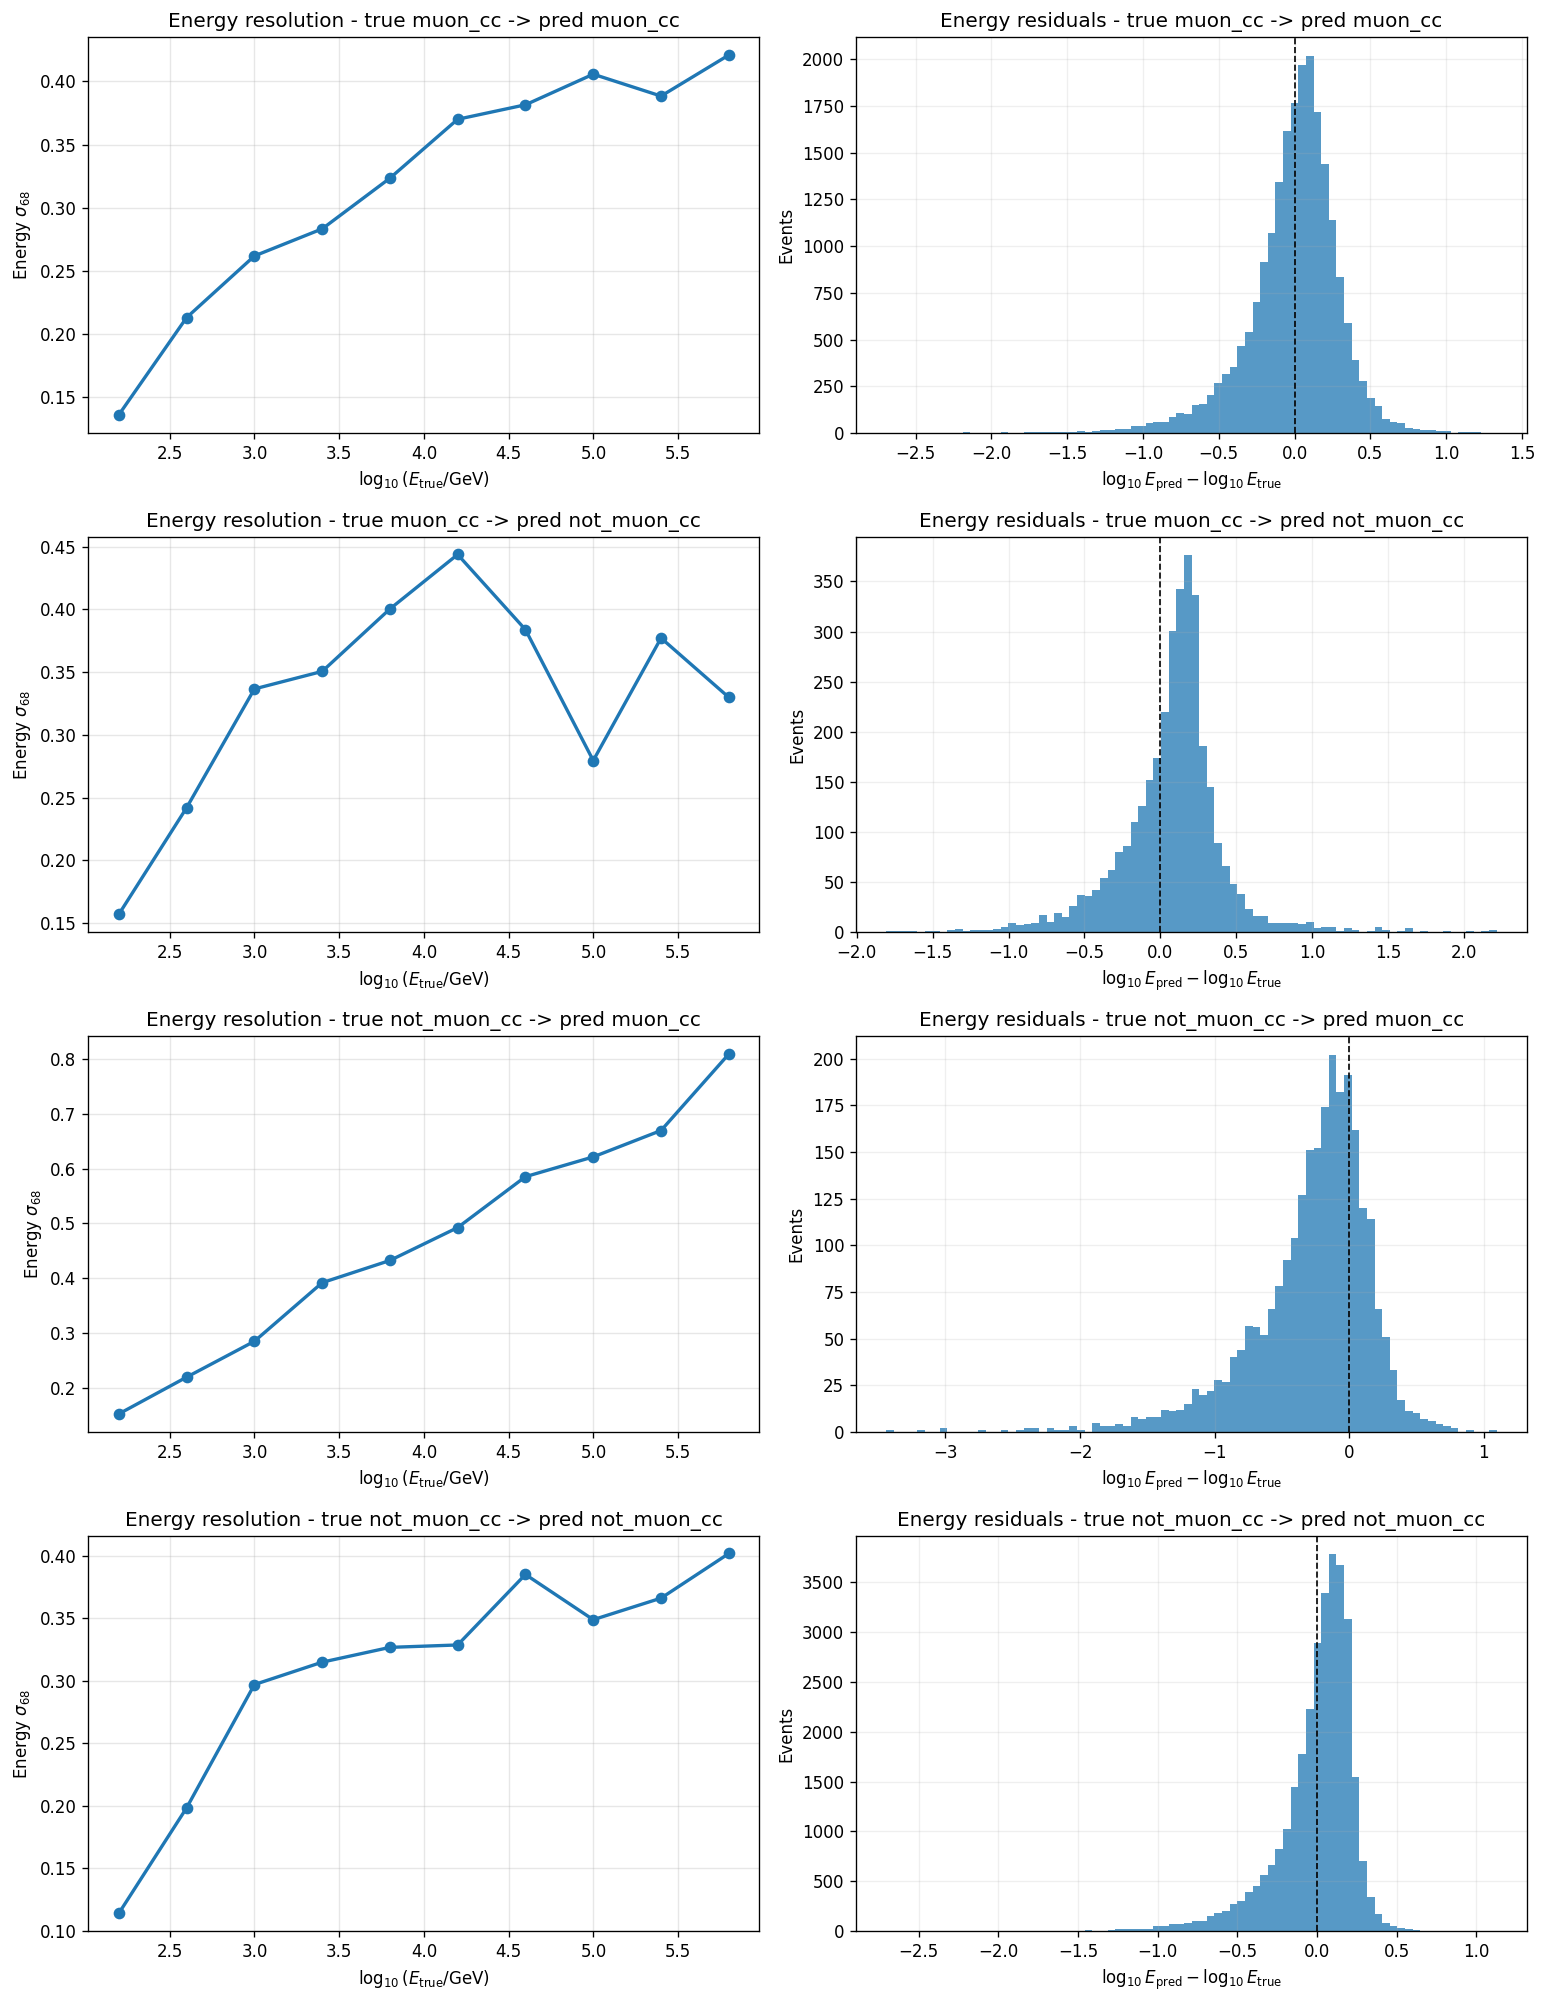

In [6]:
plot_resolution_and_residual_groups(
    energy_df,
    confusion_route_grouped_frames(energy_df),
    residual_col="energy_residual_log10",
    y_label=r"Energy $\sigma_{68}$",
    residual_xlabel=r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$",
    title_prefix="Energy",
    color="tab:blue",
)


## Section 3 - Zenith


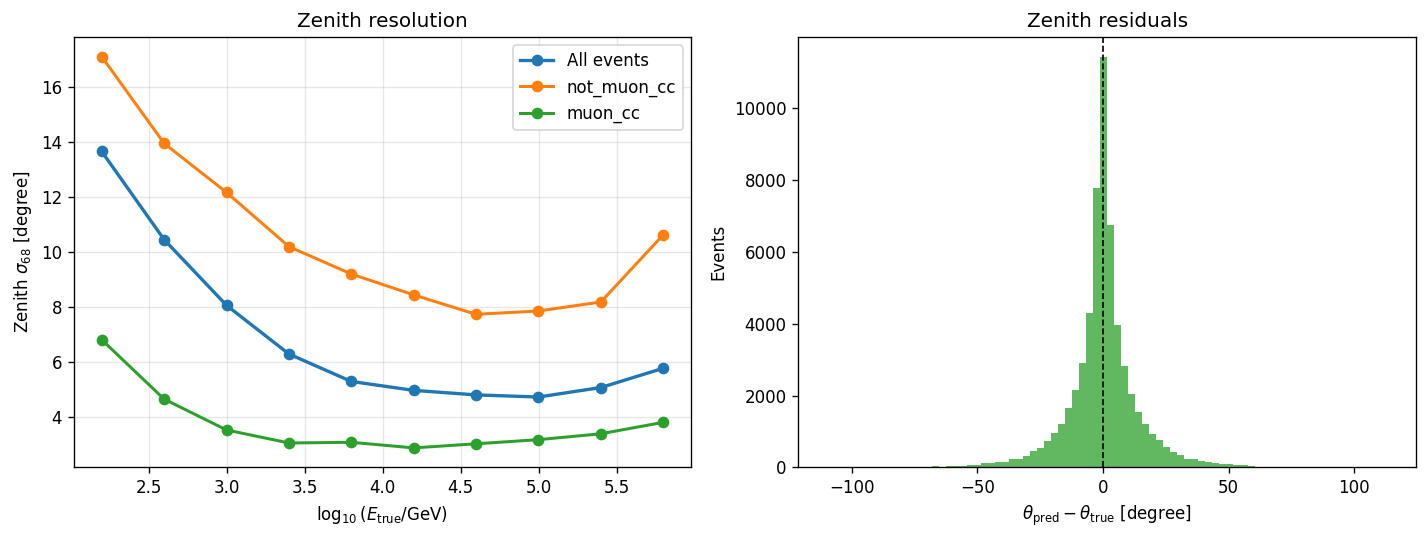

In [7]:
zenith_residual_col = "zenith_residual_zenith_degree" if "zenith_residual_zenith_degree" in df.columns else "residual_zenith_degree"
zenith_cols = ["true_log10_energy", zenith_residual_col, true_class_col, analysis_group_col, pid_interaction_exact_col, confusion_route_col]
zenith_df = df[[col for col in zenith_cols if col in df.columns]].dropna().copy()
zenith_df = zenith_df.rename(columns={zenith_residual_col: "zenith_residual_degree"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(zenith_df, "true_log10_energy", "zenith_residual_degree", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in zenith_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "zenith_residual_degree", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"Zenith $\sigma_{68}$ [degree]")
axes[0].set_title("Zenith resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(zenith_df["zenith_residual_degree"], bins=80, histtype="stepfilled", alpha=0.75, color="tab:green")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]")
axes[1].set_ylabel("Events")
axes[1].set_title("Zenith residuals")
fig.tight_layout()
plt.show()


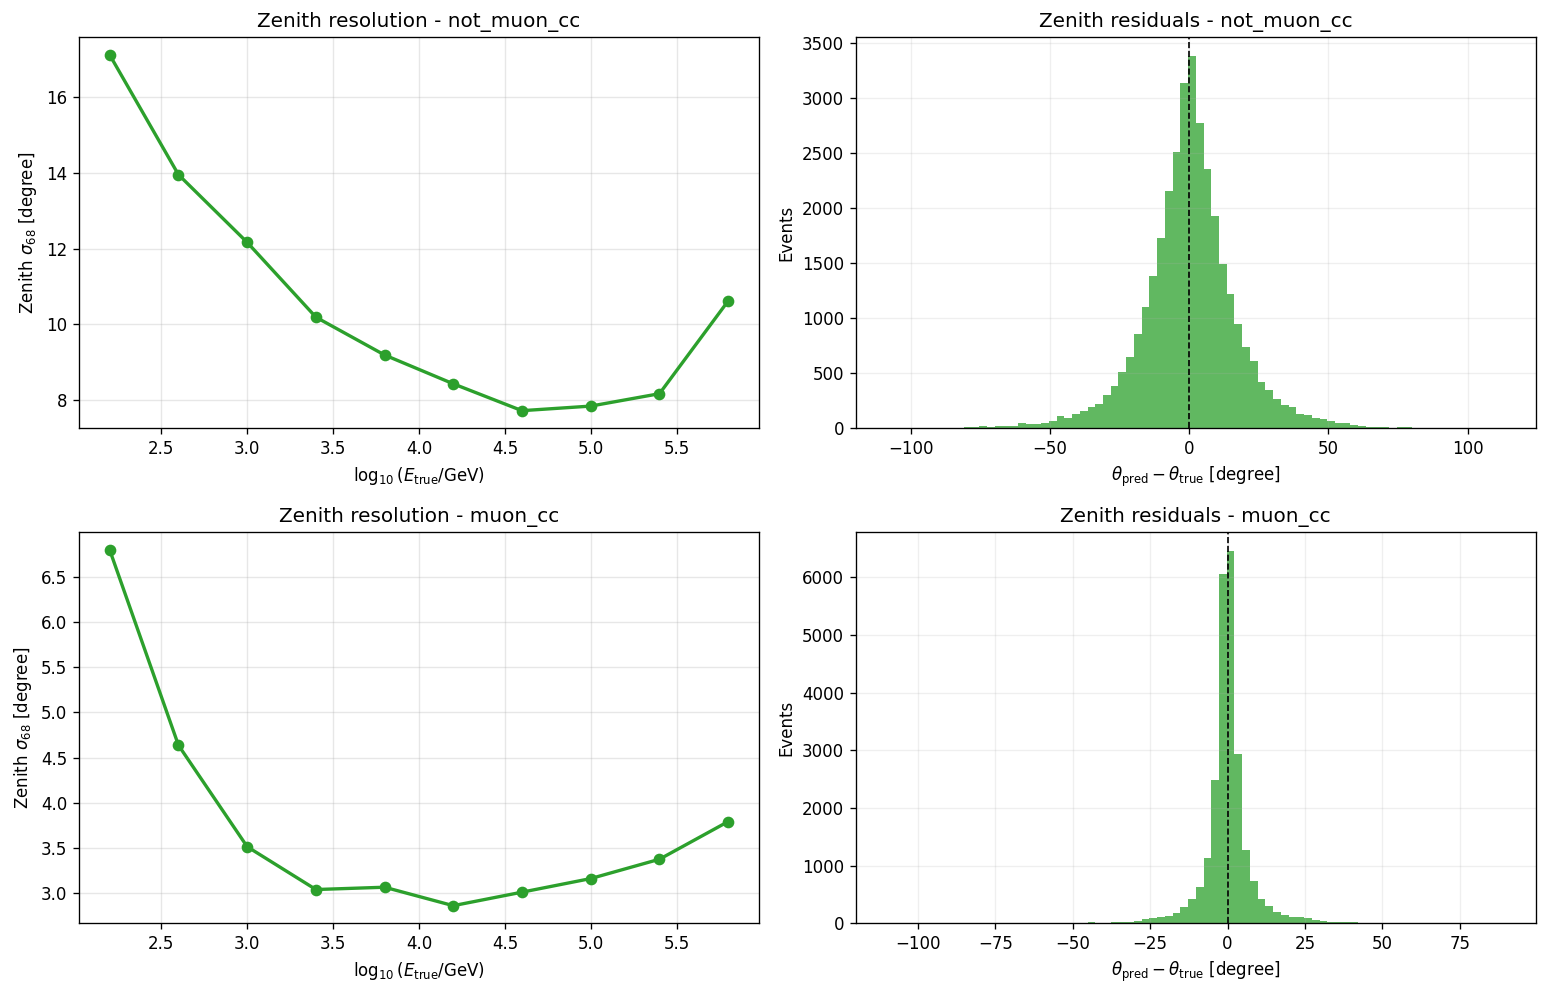

In [8]:
plot_resolution_and_residual_groups(
    zenith_df,
    class_grouped_frames(zenith_df),
    residual_col="zenith_residual_degree",
    y_label=r"Zenith $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]",
    title_prefix="Zenith",
    color="tab:green",
)


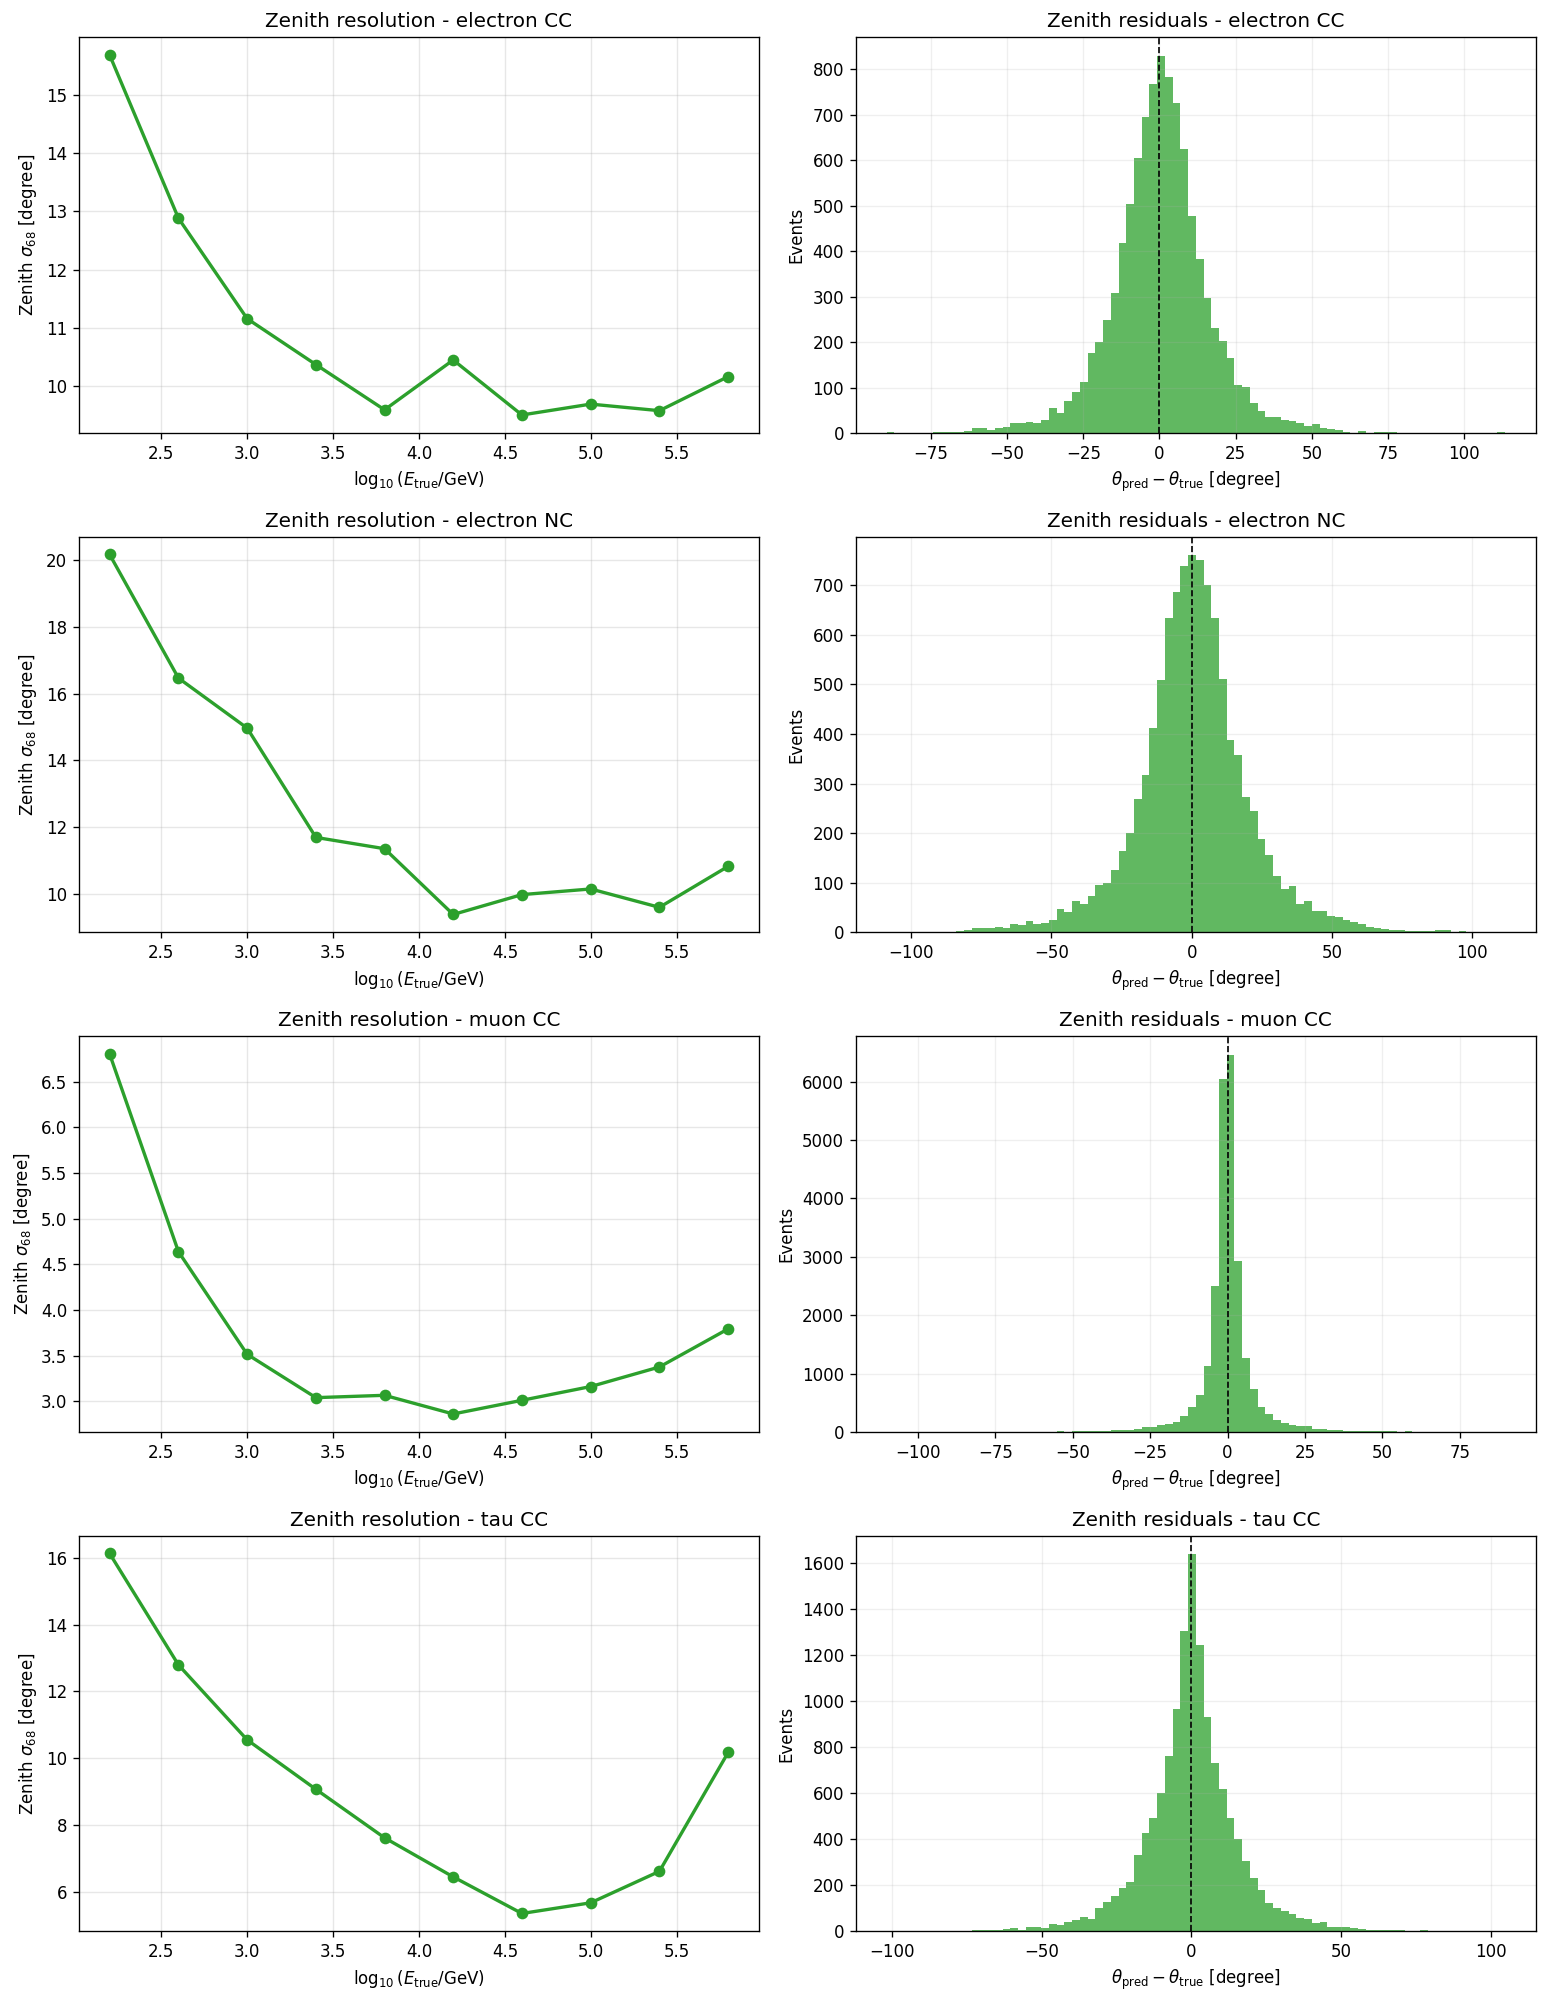

In [9]:
plot_resolution_and_residual_groups(
    zenith_df,
    pid_interaction_grouped_frames(zenith_df),
    residual_col="zenith_residual_degree",
    y_label=r"Zenith $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]",
    title_prefix="Zenith",
    color="tab:green",
)


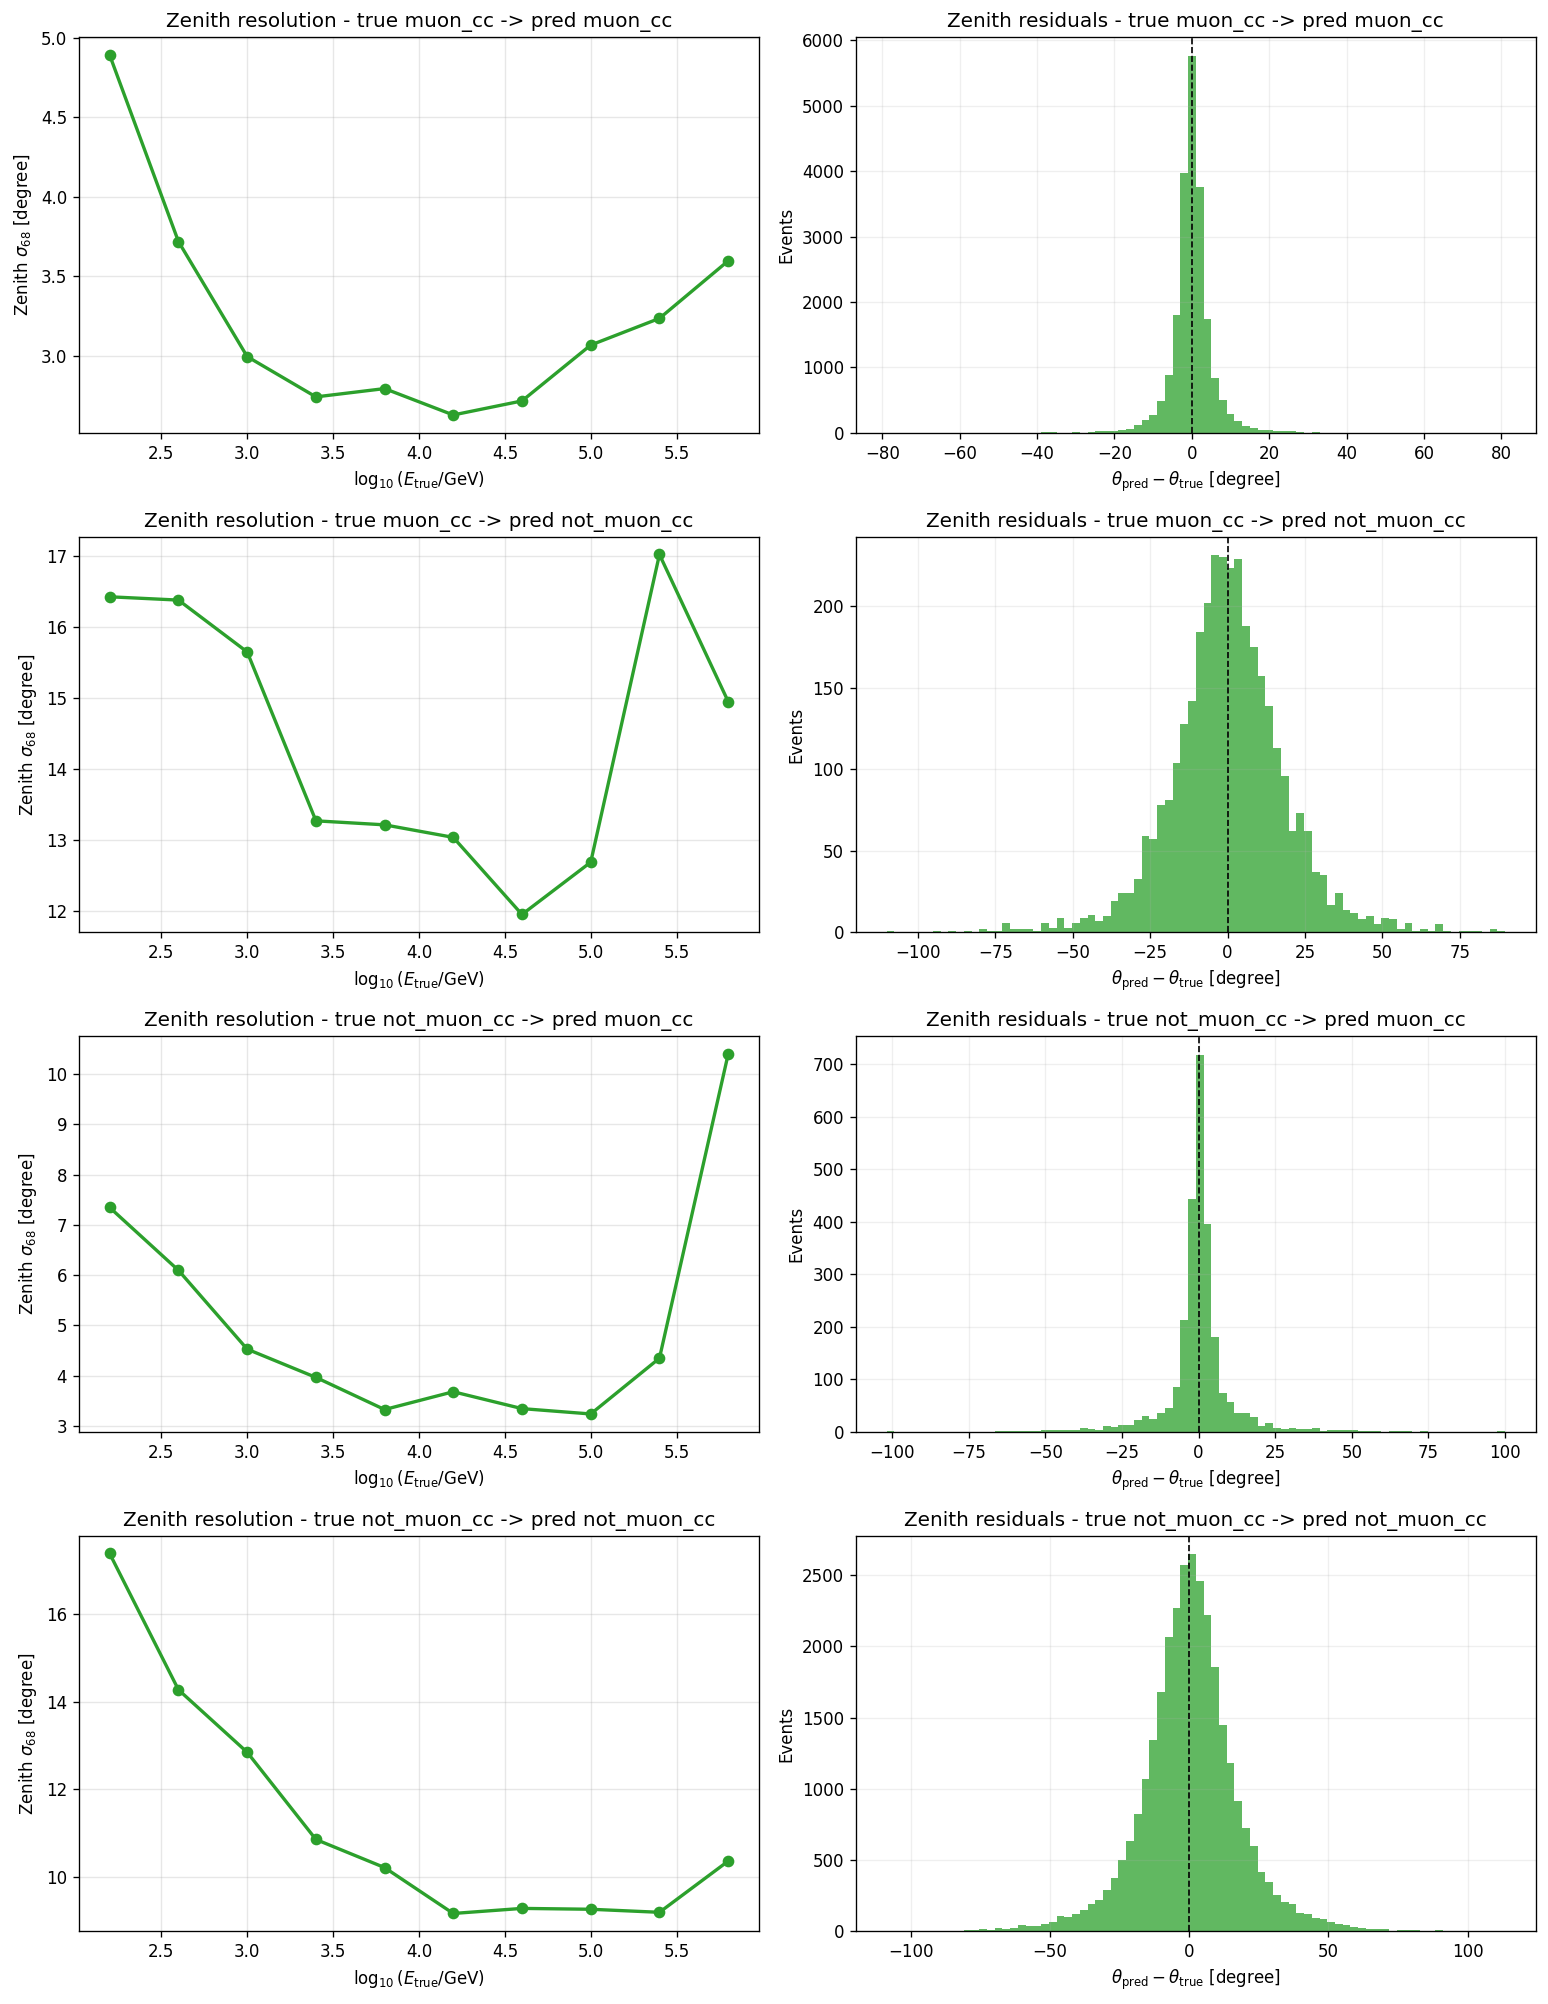

In [10]:
plot_resolution_and_residual_groups(
    zenith_df,
    confusion_route_grouped_frames(zenith_df),
    residual_col="zenith_residual_degree",
    y_label=r"Zenith $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]",
    title_prefix="Zenith",
    color="tab:green",
)


## Section 4 - Azimuth


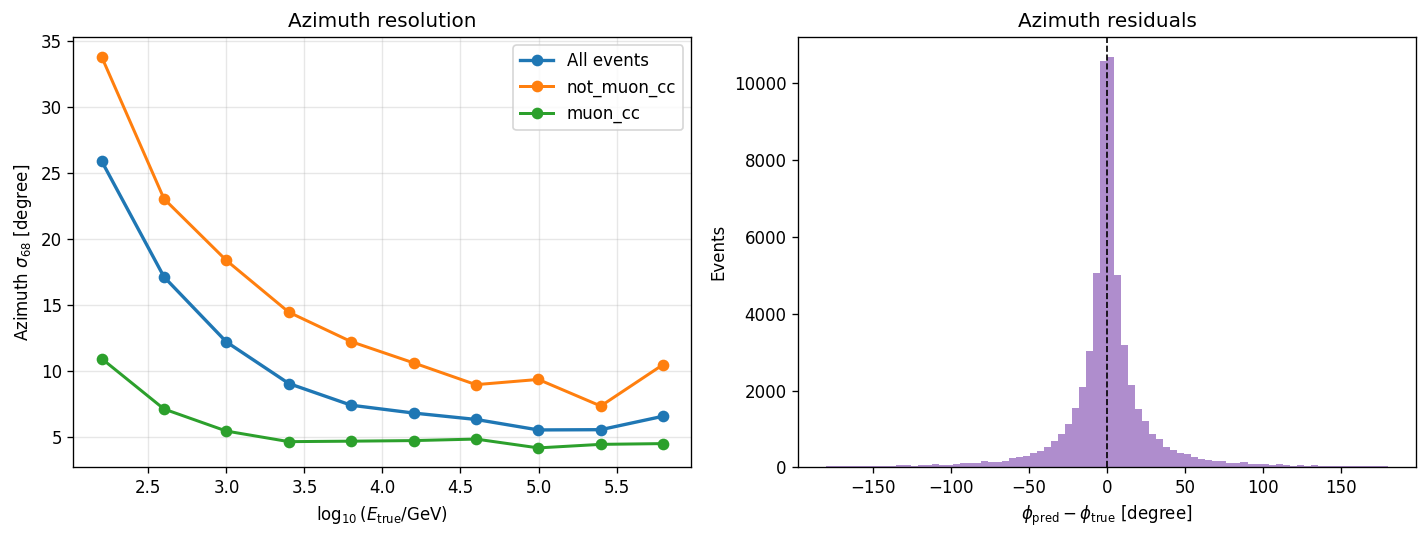

In [11]:
azimuth_residual_col = "azimuth_residual_azimuth_degree" if "azimuth_residual_azimuth_degree" in df.columns else "residual_azimuth_degree"
azimuth_cols = ["true_log10_energy", azimuth_residual_col, true_class_col, analysis_group_col, pid_interaction_exact_col, confusion_route_col]
azimuth_df = df[[col for col in azimuth_cols if col in df.columns]].dropna().copy()
azimuth_df = azimuth_df.rename(columns={azimuth_residual_col: "azimuth_residual_degree"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(azimuth_df, "true_log10_energy", "azimuth_residual_degree", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in azimuth_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "azimuth_residual_degree", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"Azimuth $\sigma_{68}$ [degree]")
axes[0].set_title("Azimuth resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(azimuth_df["azimuth_residual_degree"], bins=80, histtype="stepfilled", alpha=0.75, color="tab:purple")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]")
axes[1].set_ylabel("Events")
axes[1].set_title("Azimuth residuals")
fig.tight_layout()
plt.show()


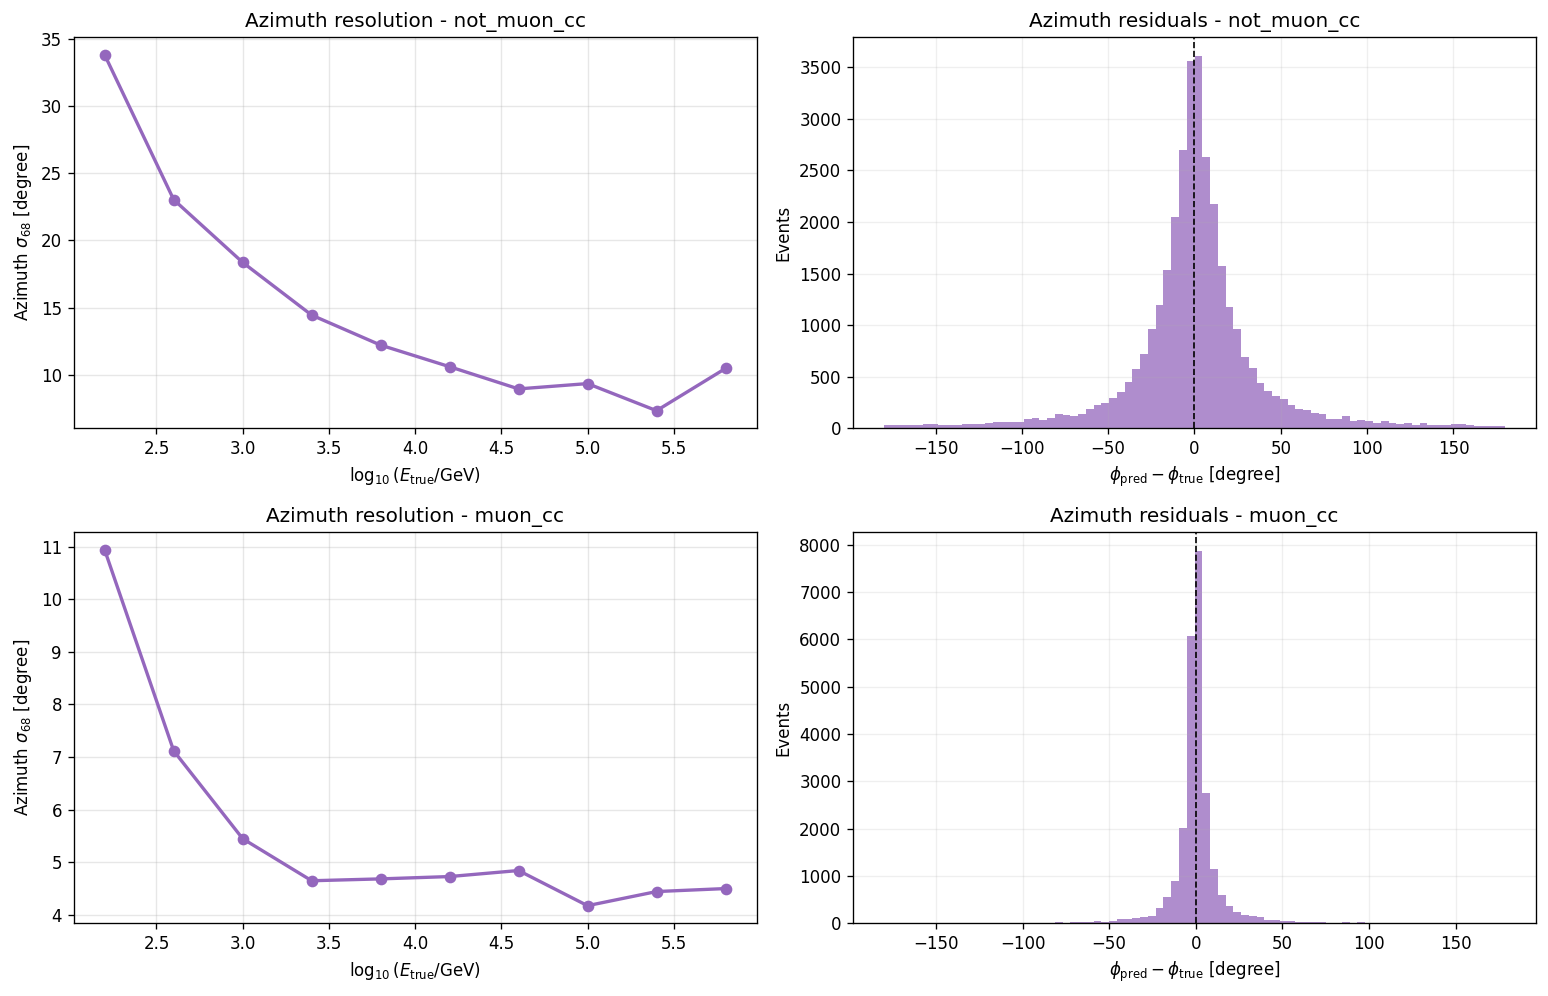

In [12]:
plot_resolution_and_residual_groups(
    azimuth_df,
    class_grouped_frames(azimuth_df),
    residual_col="azimuth_residual_degree",
    y_label=r"Azimuth $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]",
    title_prefix="Azimuth",
    color="tab:purple",
)


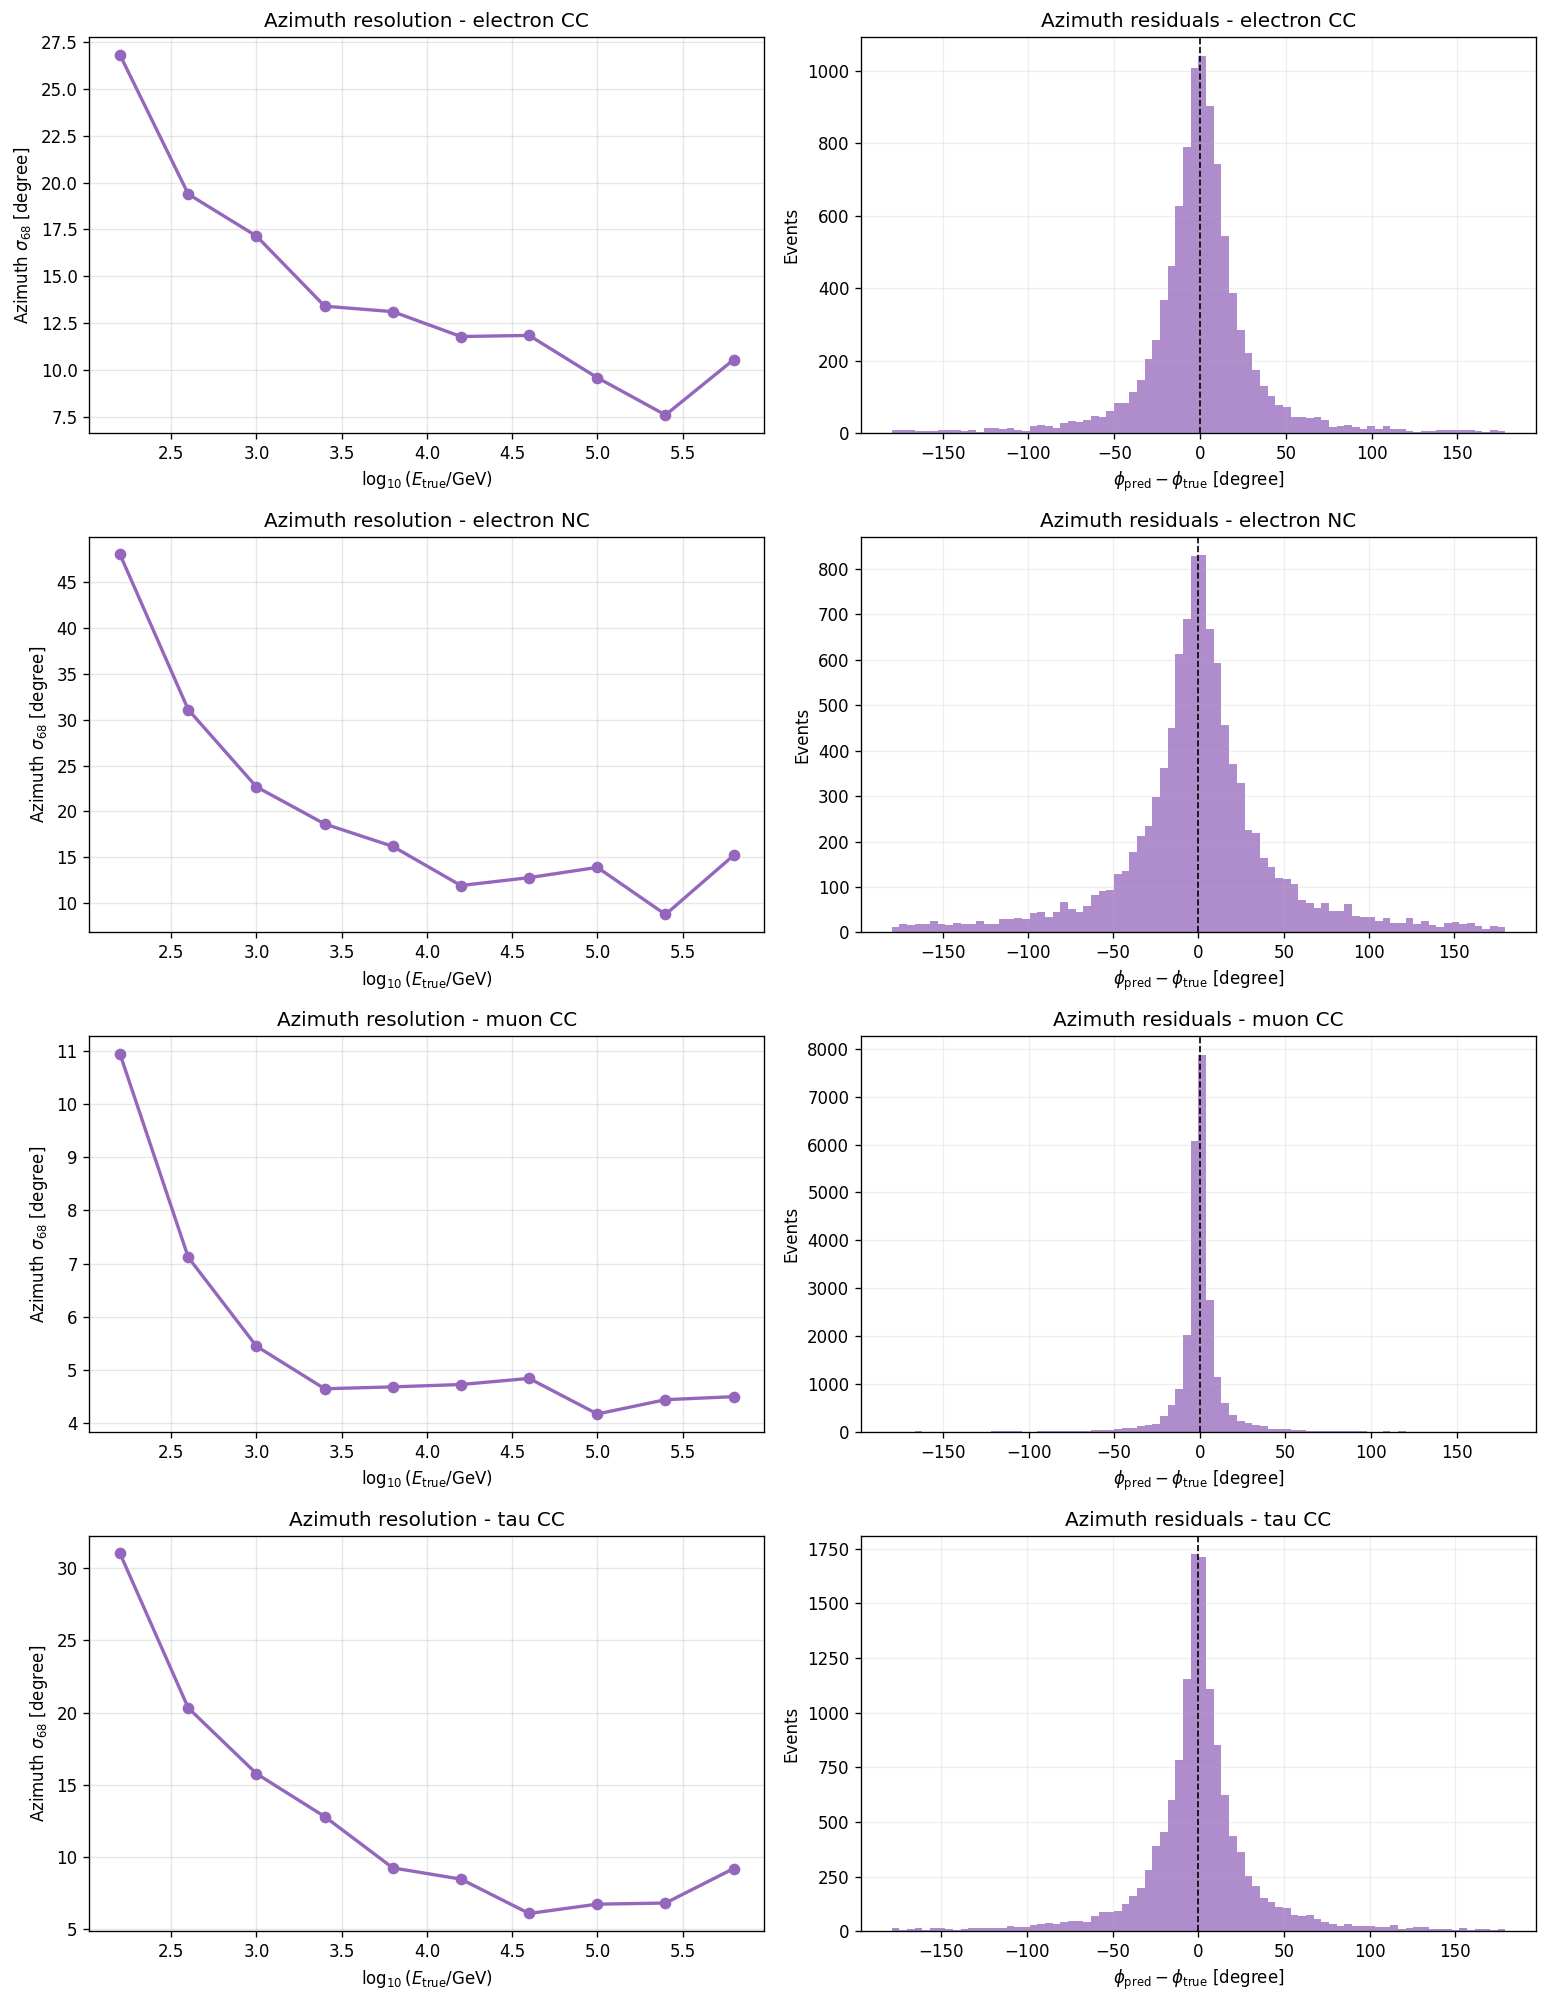

In [13]:
plot_resolution_and_residual_groups(
    azimuth_df,
    pid_interaction_grouped_frames(azimuth_df),
    residual_col="azimuth_residual_degree",
    y_label=r"Azimuth $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]",
    title_prefix="Azimuth",
    color="tab:purple",
)


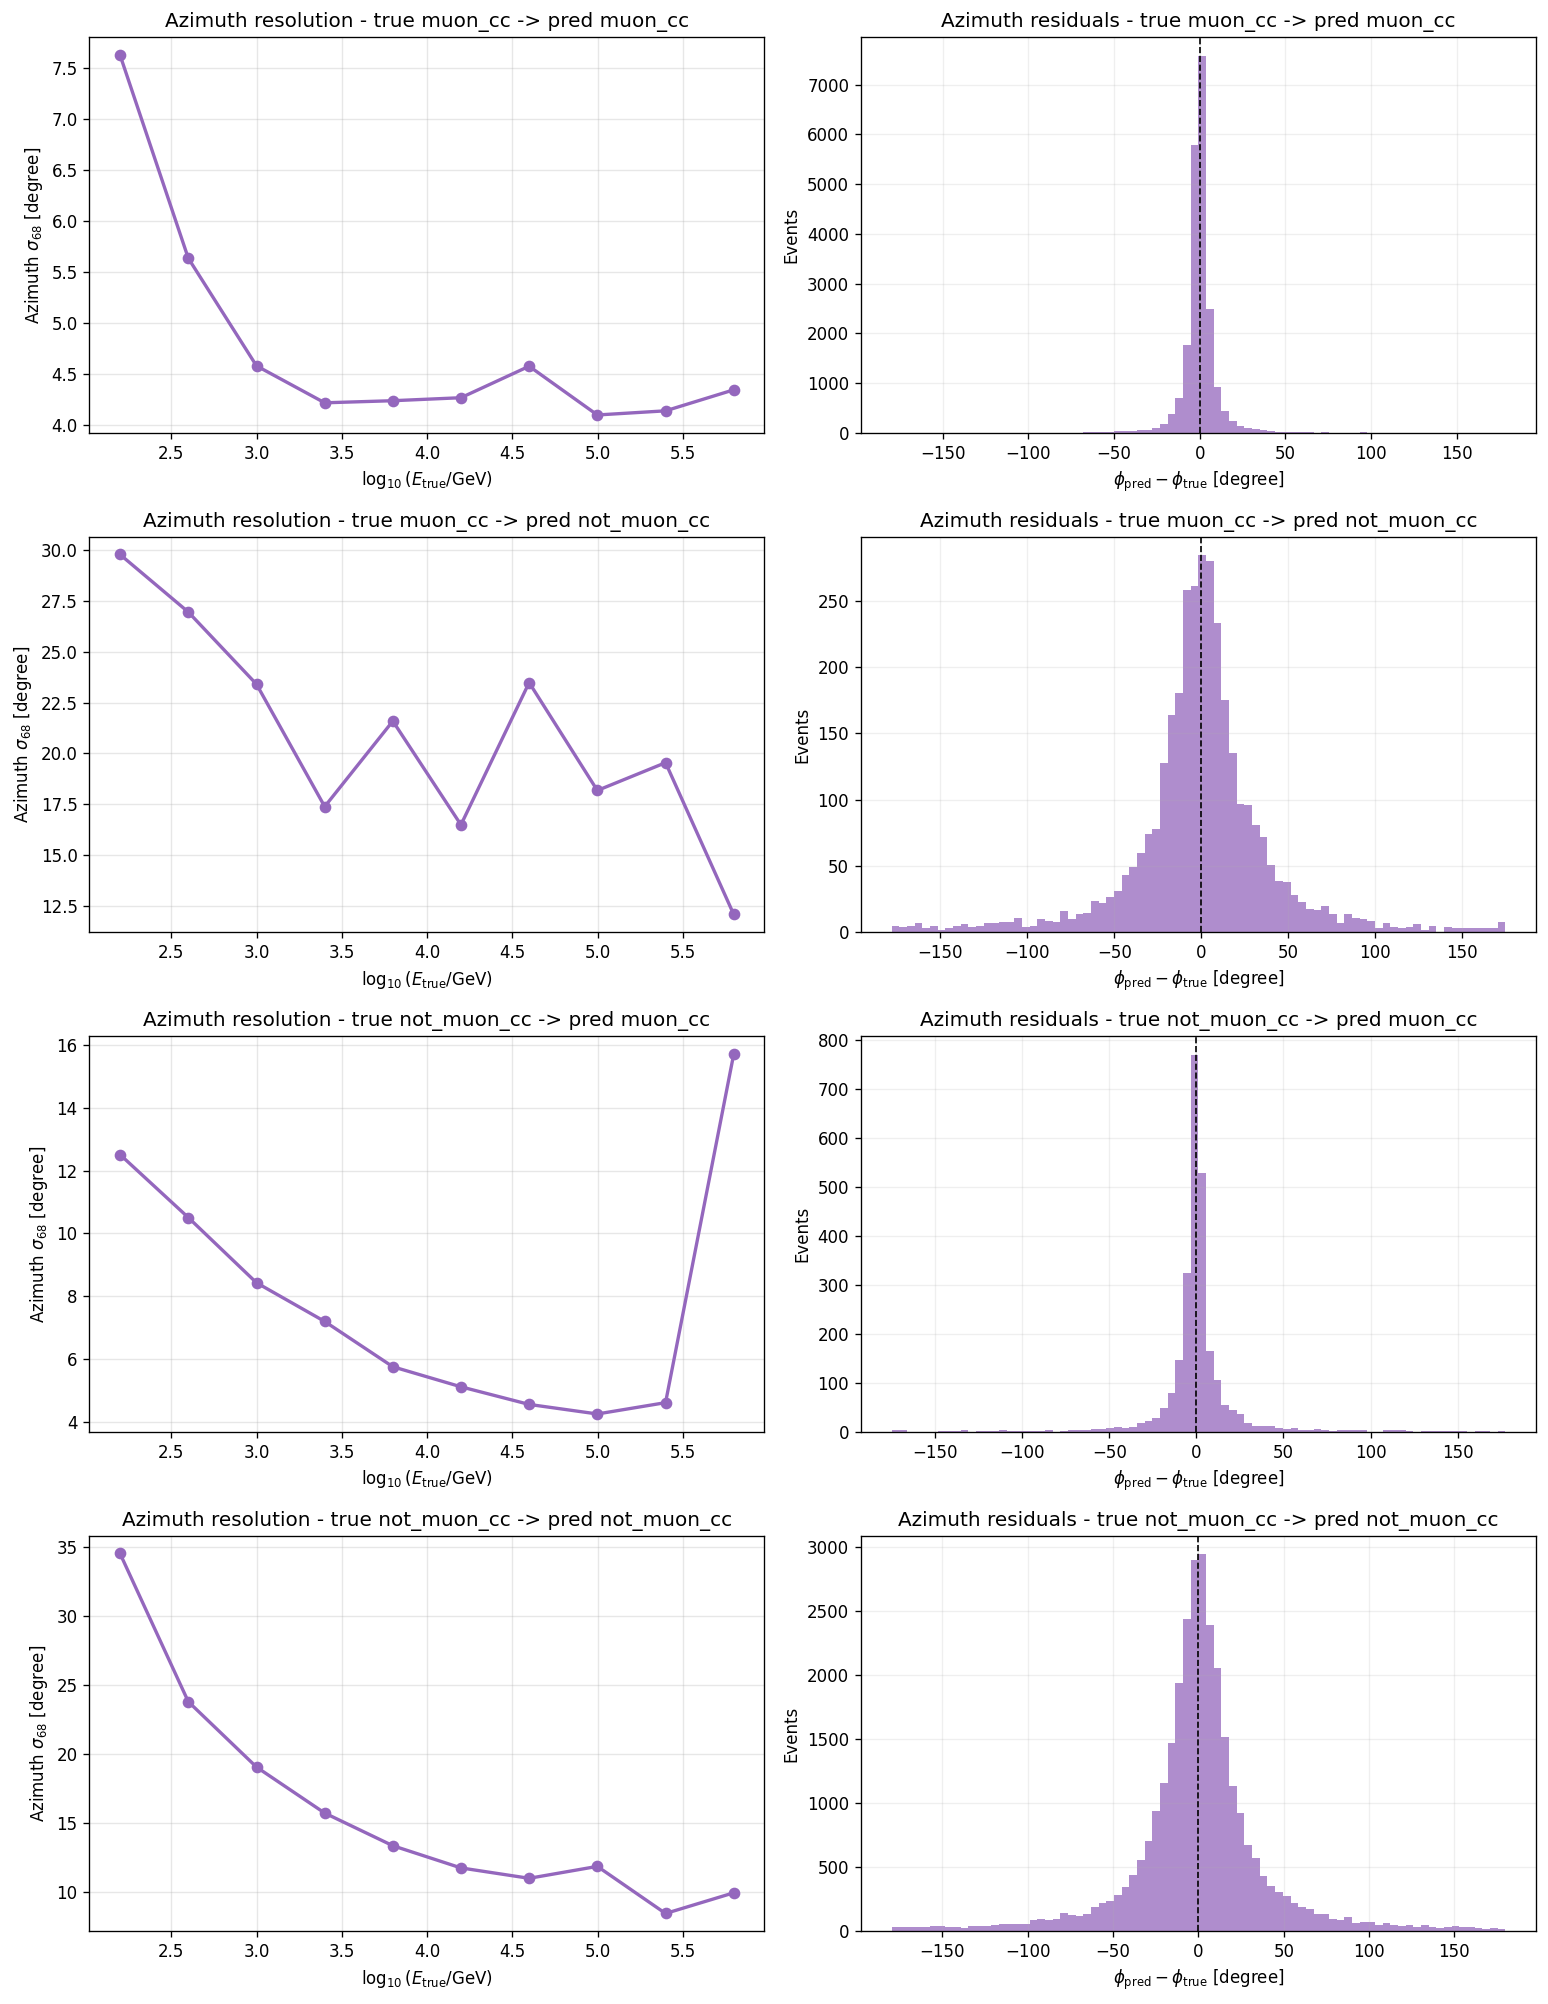

In [14]:
plot_resolution_and_residual_groups(
    azimuth_df,
    confusion_route_grouped_frames(azimuth_df),
    residual_col="azimuth_residual_degree",
    y_label=r"Azimuth $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]",
    title_prefix="Azimuth",
    color="tab:purple",
)


## Section 5 - Opening Angle


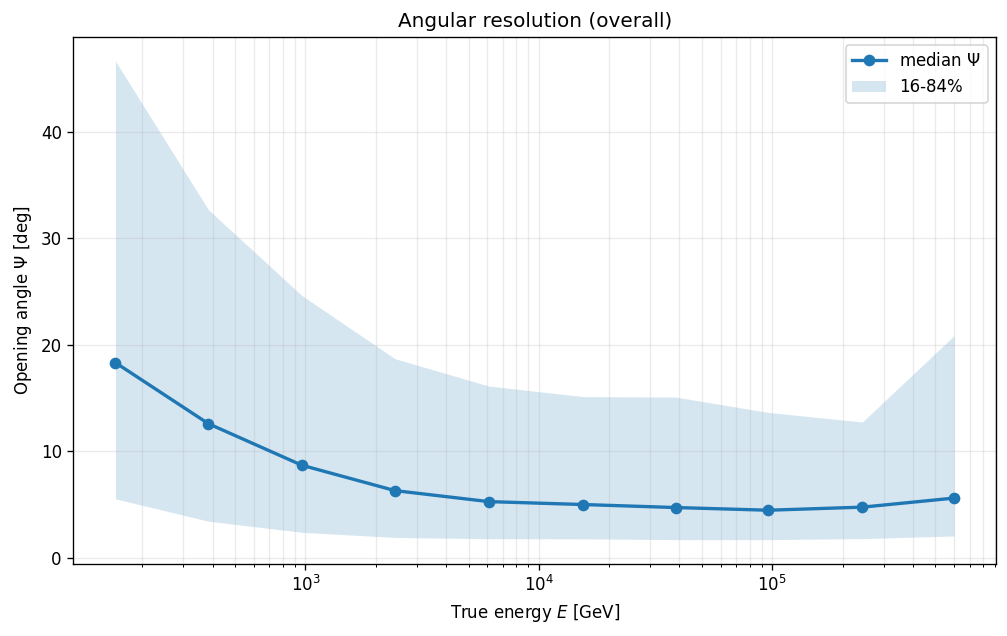

,bin_center_energy,count,median_psi,p16,p84
0,153.484001,21254,18.322603,5.519277,46.689150
1,384.396007,13268,12.577763,3.410722,32.693660
2,965.962544,8245,8.674262,2.369257,24.631137
3,2419.976215,5545,6.288866,1.885099,18.693202
4,6101.321882,3814,5.254790,1.770137,16.120199
5,15475.177099,2544,4.981070,1.753873,15.129835
6,38678.201366,1659,4.697575,1.681385,15.080993
7,96036.878243,1086,4.446507,1.680650,13.641395
8,243068.531884,764,4.734884,1.776162,12.739191
9,600483.376842,484,5.587046,2.024638,20.861617


In [15]:
def opening_angle_deg(theta_true, phi_true, theta_pred, phi_pred):
    cos_delta = (
        np.sin(theta_true) * np.sin(theta_pred) * np.cos(phi_true - phi_pred)
        + np.cos(theta_true) * np.cos(theta_pred)
    )
    return np.degrees(np.arccos(np.clip(cos_delta, -1.0, 1.0)))

zen_true = "zenith_true_zenith_radian" if "zenith_true_zenith_radian" in df.columns else "true_zenith_radian"
zen_pred = "zenith_pred_zenith_radian" if "zenith_pred_zenith_radian" in df.columns else "pred_zenith_radian"
azi_true = "azimuth_true_azimuth_radian" if "azimuth_true_azimuth_radian" in df.columns else "true_azimuth_radian"
azi_pred = "azimuth_pred_azimuth_radian" if "azimuth_pred_azimuth_radian" in df.columns else "pred_azimuth_radian"

opening_cols = ["true_energy", "true_log10_energy", true_class_col, analysis_group_col, pid_interaction_exact_col, zen_true, zen_pred, azi_true, azi_pred]
opening_df = df[opening_cols].dropna().copy()
opening_df["opening_angle_degree"] = opening_angle_deg(opening_df[zen_true], opening_df[azi_true], opening_df[zen_pred], opening_df[azi_pred])

opening_df["energy_bin"] = pd.cut(opening_df["true_log10_energy"], bins=bins, include_lowest=True)
opening_summary = (
    opening_df.groupby("energy_bin", observed=True)
    .agg(
        bin_center_log10=("true_log10_energy", "mean"),
        count=("opening_angle_degree", "size"),
        median_psi=("opening_angle_degree", "median"),
        p16=("opening_angle_degree", lambda x: np.percentile(x, 16)),
        p84=("opening_angle_degree", lambda x: np.percentile(x, 84)),
    )
    .reset_index(drop=True)
)
opening_summary = opening_summary[opening_summary["count"] > 0].copy()
opening_summary["bin_center_energy"] = 10 ** opening_summary["bin_center_log10"]

fig, ax = plt.subplots(figsize=(8.5, 5.4))
ax.plot(
    opening_summary["bin_center_energy"], opening_summary["median_psi"],
    marker="o", linewidth=2, color="tab:blue", label=r"median $\Psi$"
)
ax.fill_between(
    opening_summary["bin_center_energy"], opening_summary["p16"], opening_summary["p84"],
    color="tab:blue", alpha=0.18, linewidth=0, label="16-84%"
)
ax.set_xscale("log")
ax.set_xlabel(r"True energy $E$ [GeV]")
ax.set_ylabel(r"Opening angle $\Psi$ [deg]")
ax.set_title("Angular resolution (overall)")
ax.grid(True, alpha=0.25, which="both")
ax.legend()
fig.tight_layout()
plt.show()

opening_summary[["bin_center_energy", "count", "median_psi", "p16", "p84"]]


### Opening Angle by Flavor


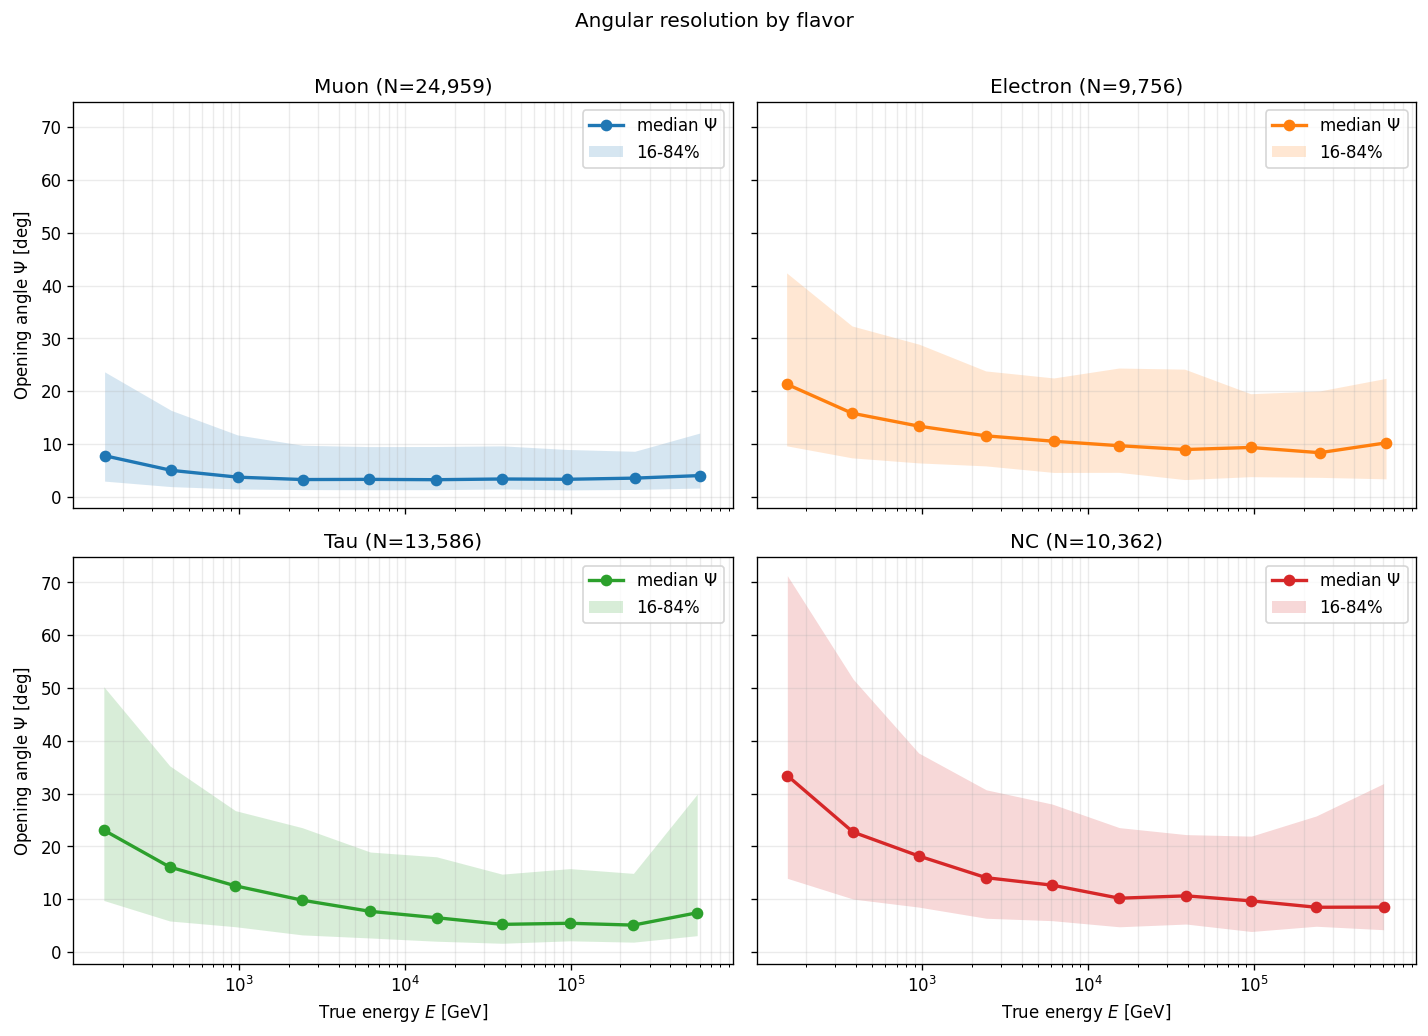

,flavor,bin_center_energy,count,median_psi,p16,p84
0,Muon,154.620665,7140,7.798605,2.984706,23.670112
1,Muon,389.980431,4981,5.024530,1.942703,16.375958
2,Muon,980.761255,3804,3.735450,1.491665,11.722328
3,Muon,2423.164105,2965,3.281447,1.384448,9.772040
4,Muon,6052.827368,2219,3.314493,1.350803,9.524671
5,Muon,15480.523412,1468,3.253673,1.369728,9.538303
6,Muon,38655.449070,988,3.385244,1.505762,9.663415
7,Muon,94983.884669,652,3.330091,1.322699,8.976041
8,Muon,243988.211881,459,3.550493,1.406760,8.633261
9,Muon,601205.837412,283,4.031616,1.673777,12.080221


In [16]:
flavor_opening_df = df[["pid", "is_CC", "true_log10_energy", zen_true, zen_pred, azi_true, azi_pred]].dropna().copy()
flavor_opening_df["opening_angle_degree"] = opening_angle_deg(
    flavor_opening_df[zen_true], flavor_opening_df[azi_true],
    flavor_opening_df[zen_pred], flavor_opening_df[azi_pred]
)

pid_flavor = flavor_opening_df["pid"].abs().astype(int).map({12: "Electron", 14: "Muon", 16: "Tau"})
flavor_opening_df["flavor"] = np.where(
    flavor_opening_df["is_CC"].astype(int) == 0,
    "NC",
    pid_flavor,
)
flavor_opening_df = flavor_opening_df.dropna(subset=["flavor"])
flavor_opening_df["energy_bin"] = pd.cut(
    flavor_opening_df["true_log10_energy"], bins=bins, include_lowest=True
)

flavor_order = ["Muon", "Electron", "Tau", "NC"]
flavor_colors = {
    "Muon": "tab:blue",
    "Electron": "tab:orange",
    "Tau": "tab:green",
    "NC": "tab:red",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharex=True, sharey=True)
flavor_opening_summaries = {}

for ax, flavor in zip(axes.flat, flavor_order):
    flavor_df = flavor_opening_df[flavor_opening_df["flavor"] == flavor]
    summary = (
        flavor_df.groupby("energy_bin", observed=True)
        .agg(
            bin_center_log10=("true_log10_energy", "mean"),
            count=("opening_angle_degree", "size"),
            median_psi=("opening_angle_degree", "median"),
            p16=("opening_angle_degree", lambda x: np.percentile(x, 16)),
            p84=("opening_angle_degree", lambda x: np.percentile(x, 84)),
        )
        .reset_index(drop=True)
    )
    summary = summary[summary["count"] > 0].copy()
    summary["bin_center_energy"] = 10 ** summary["bin_center_log10"]
    flavor_opening_summaries[flavor] = summary

    color = flavor_colors[flavor]
    ax.plot(
        summary["bin_center_energy"], summary["median_psi"],
        marker="o", linewidth=2, color=color, label=r"median $\Psi$"
    )
    ax.fill_between(
        summary["bin_center_energy"], summary["p16"], summary["p84"],
        color=color, alpha=0.18, linewidth=0, label="16-84%"
    )
    ax.set_xscale("log")
    ax.set_title(f"{flavor} (N={len(flavor_df):,})")
    ax.grid(True, alpha=0.25, which="both")
    ax.legend()

for ax in axes[-1, :]:
    ax.set_xlabel(r"True energy $E$ [GeV]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Opening angle $\Psi$ [deg]")

fig.suptitle("Angular resolution by flavor", y=1.01)
fig.tight_layout()
plt.show()

pd.concat(
    [summary.assign(flavor=flavor) for flavor, summary in flavor_opening_summaries.items()],
    ignore_index=True,
)[["flavor", "bin_center_energy", "count", "median_psi", "p16", "p84"]]
